In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_equations import bisec, Newt_Rap, Secant_mth

import lib_plot

## **Secant Method**

c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:183: RuntimeWarning: 
Maximum iterations reached for x0 = 0.00, x1=0.48
  warnings.warn(f'\nMaximum iterations reached for x0 = {x0:.2f}, x1={x1:.2f}', RuntimeWarning)


N iter = 500


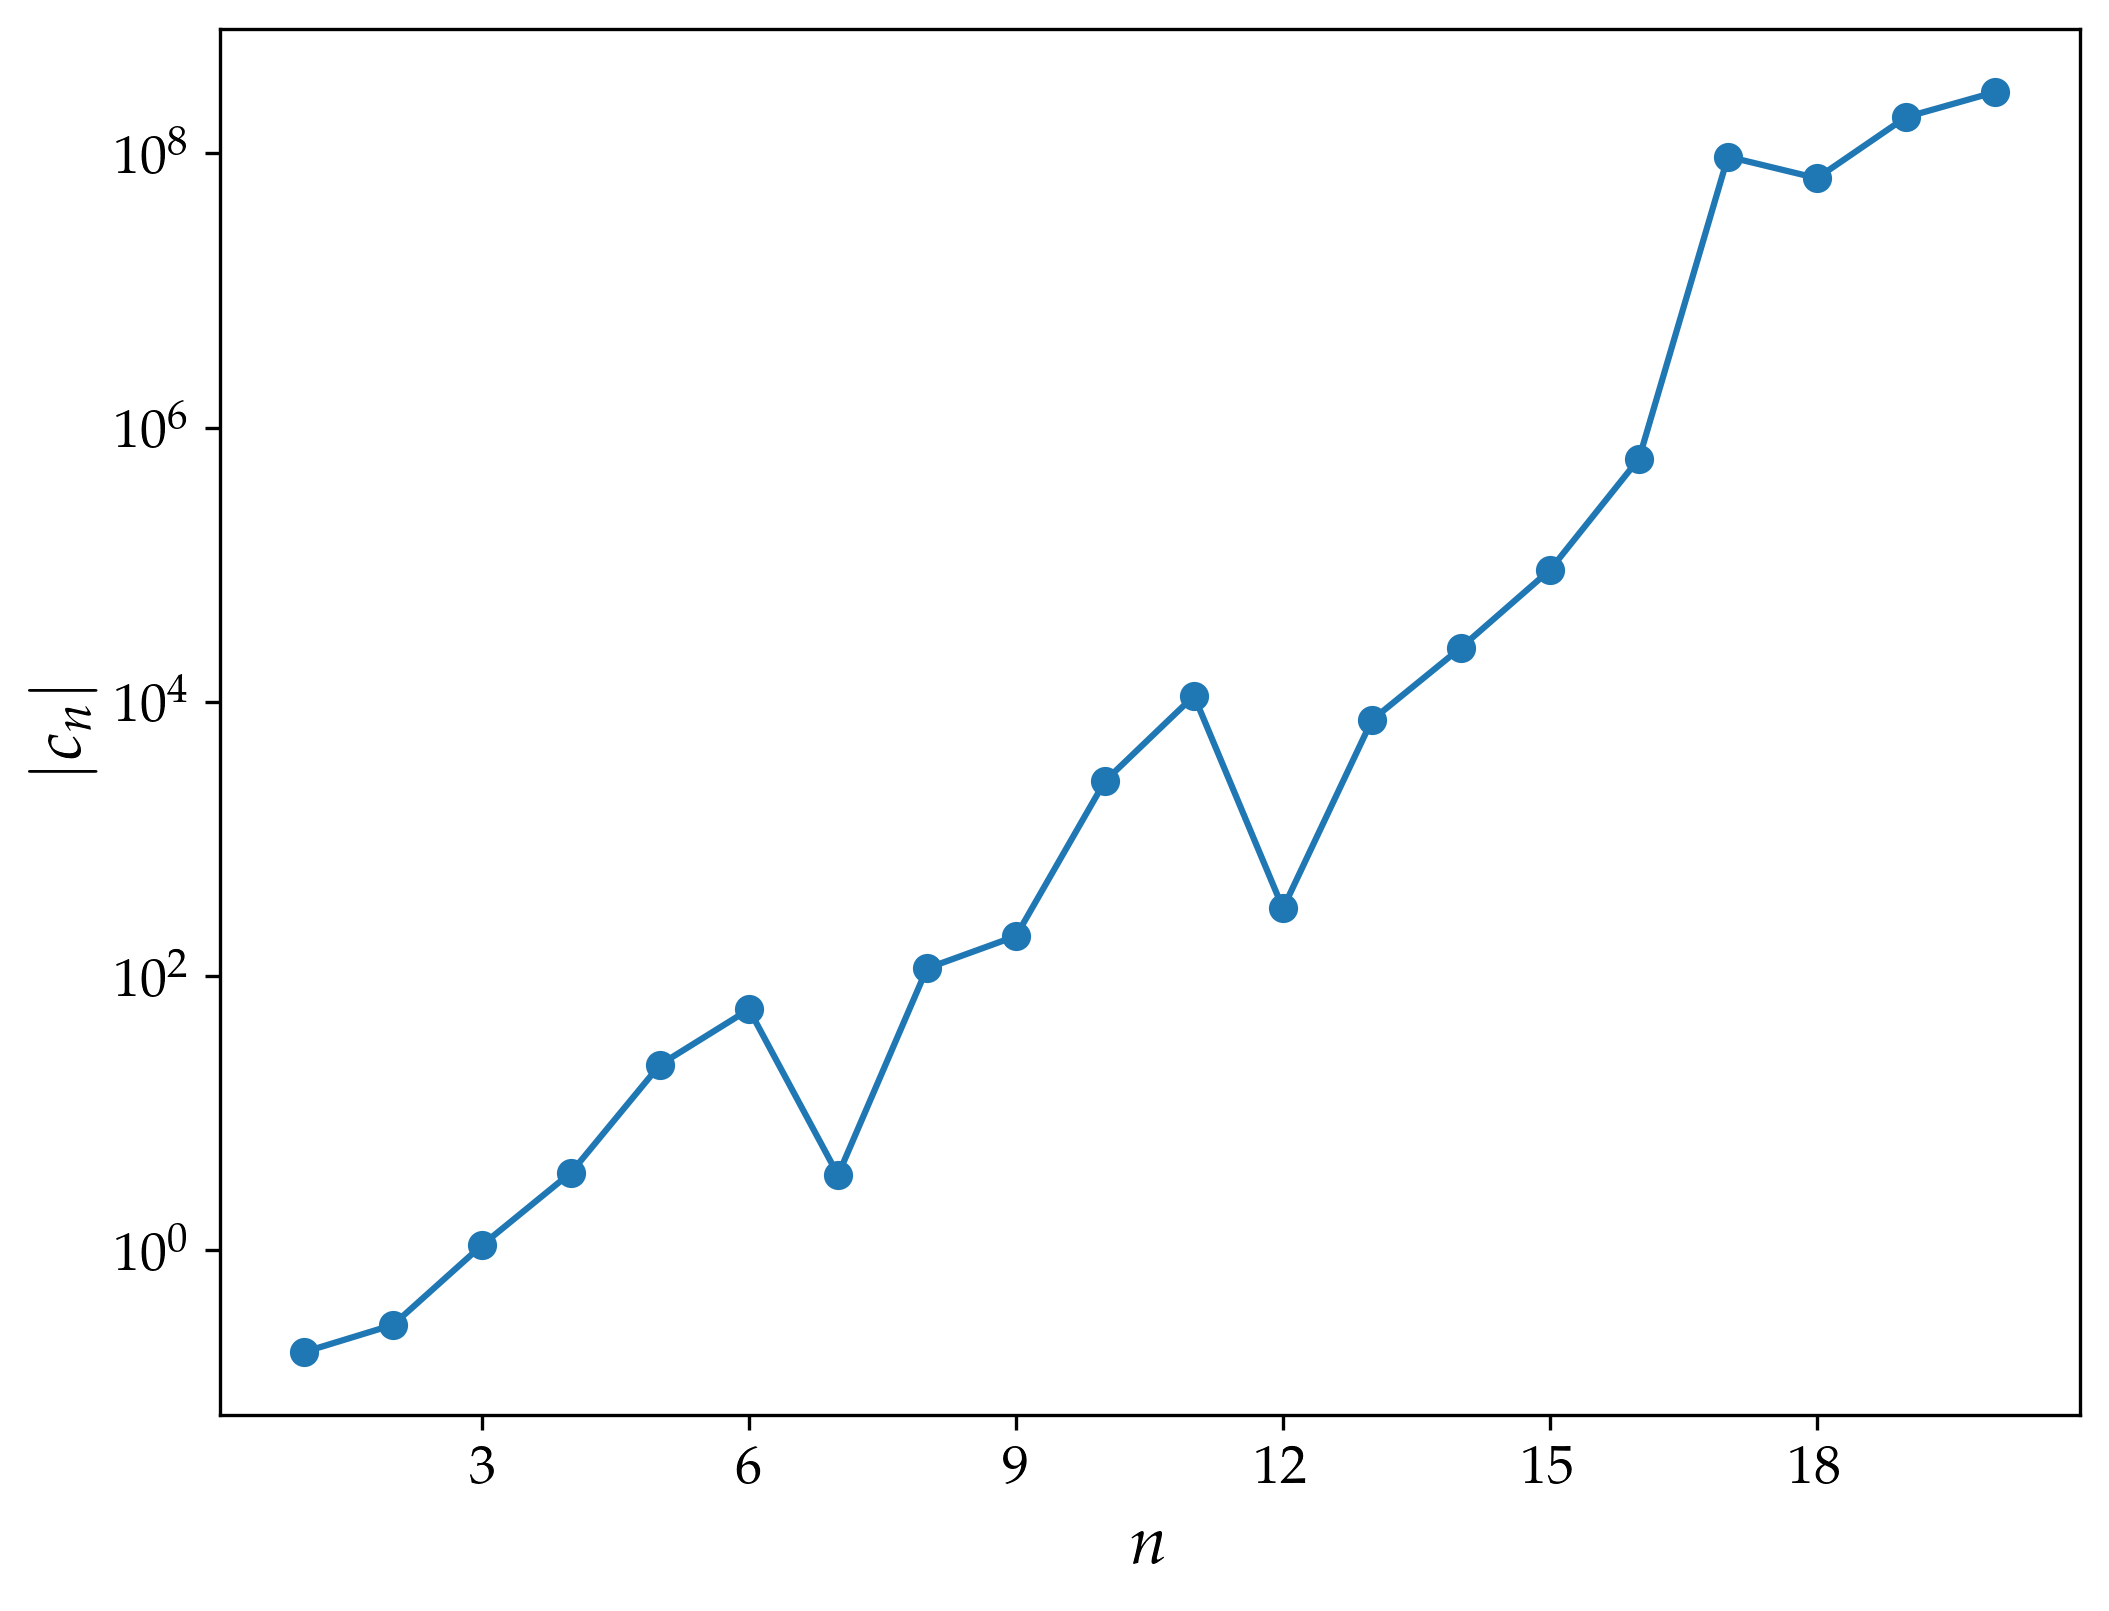

In [2]:
f = lambda x: np.tan(np.pi*x) - 6.0

c, sec_iter, sols = Secant_mth(f, x0 = 0, x1 = 0.48)
print('N iter =', sec_iter)
n_max = 20
plt.plot(np.arange(1, n_max+1), abs(sols)[:n_max], marker='o')
plt.xlabel(r'$n$')
plt.ylabel(r'$|c_n|$')
plt.yscale('log')
from matplotlib.ticker import MaxNLocator

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.savefig('plots/plot_iter.png')
plt.show()


## **Bound States in a Finite Square Well**

<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in divide
  return (1/2)*tan((1/2)*sqrt(2*E + 20))**2 + 1/2 + tan((1/2)*sqrt(2*E + 20))/sqrt(2*E + 20) - 1/2*sqrt(2)*sqrt(-E)/E


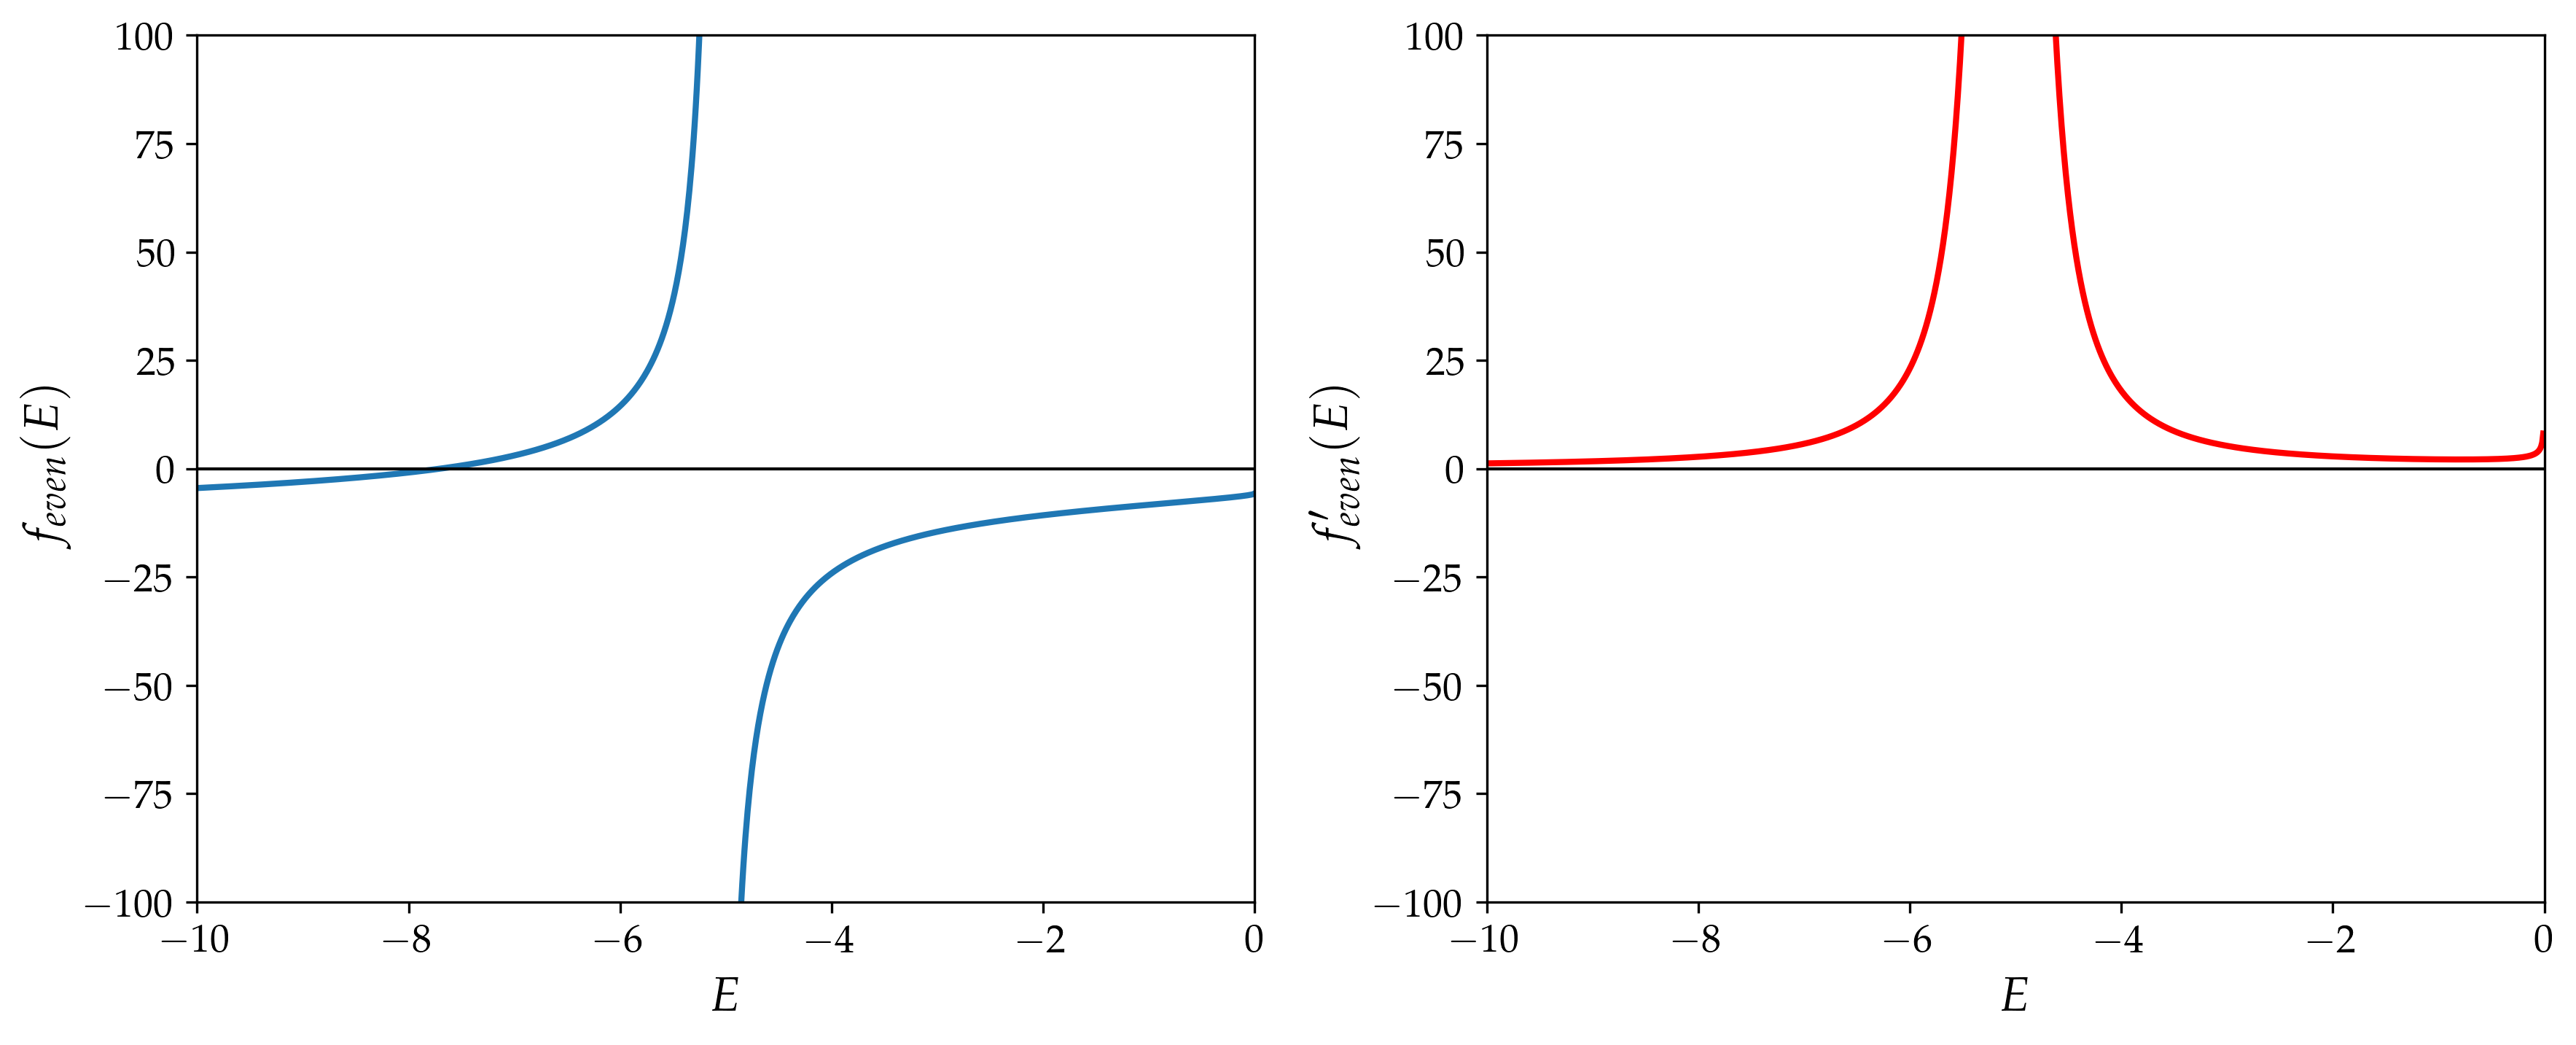

In [3]:
import sympy as sp
# ---- Parameters setup ----
V0 = 10
hbar = m = L = 1

E = sp.symbols('E', real=True)
k = sp.sqrt(2*(V0 + E))
kappa = sp.sqrt(-2*E)

sp_f_even = k*sp.tan(k/2) - kappa
sp_f_odd = k/sp.tan(k/2) + kappa
sp_df_even = sp.diff(sp_f_even, E)
sp_d2f_even = sp.diff(sp_df_even, E)
sp_df_odd = sp.diff(sp_f_odd, E)
sp_d2f_odd = sp.diff(sp_df_odd, E)

f_even = sp.lambdify(E, sp_f_even, 'numpy')
f_odd = sp.lambdify(E, sp_f_odd, 'numpy')
df_even = sp.lambdify(E, sp_df_even, 'numpy')
d2f_even = sp.lambdify(E, sp_d2f_even, 'numpy')
df_odd = sp.lambdify(E, sp_df_odd, 'numpy')
d2f_odd = sp.lambdify(E, sp_d2f_odd, 'numpy')


# ---- Plot ----
E_coo = np.linspace(-10, 0, 1000)
f_even_E = f_even(E_coo)
df_even_E = df_even(E_coo)

soglia = 1e5
f_even_E_clean = np.where(np.abs(f_even_E) > soglia, np.nan, f_even_E)
df_even_E_clean = np.where(np.abs(df_even_E) > soglia, np.nan, df_even_E)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax1.plot(E_coo, f_even_E_clean, lw=2)
ax1.axhline(0, color='black', lw=1)
ax1.set_ylabel(r'$f_{even}(E)$')
ax1.set_xlabel(r'$E$')
ax1.set_ylim(-100, 100)

ax2.plot(E_coo, df_even_E_clean, lw=2, color='red')
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel(r"$f'_{even}(E)$")
ax2.set_xlabel(r'$E$')
ax2.set_ylim(-100, 100)

plt.xlim(-10, 0)
plt.tight_layout()
plt.savefig('plots/f_even.png')
plt.show()


Bisection        c = -7.7050092507390815
                 iters = 47

Regula Falsi     c = -7.705009250739083
                 iters = 24

Secant           c = -7.7050092507390815
                 iters = 9

Newton-Raphson   c = -7.7050092507390815
                 iters = 8


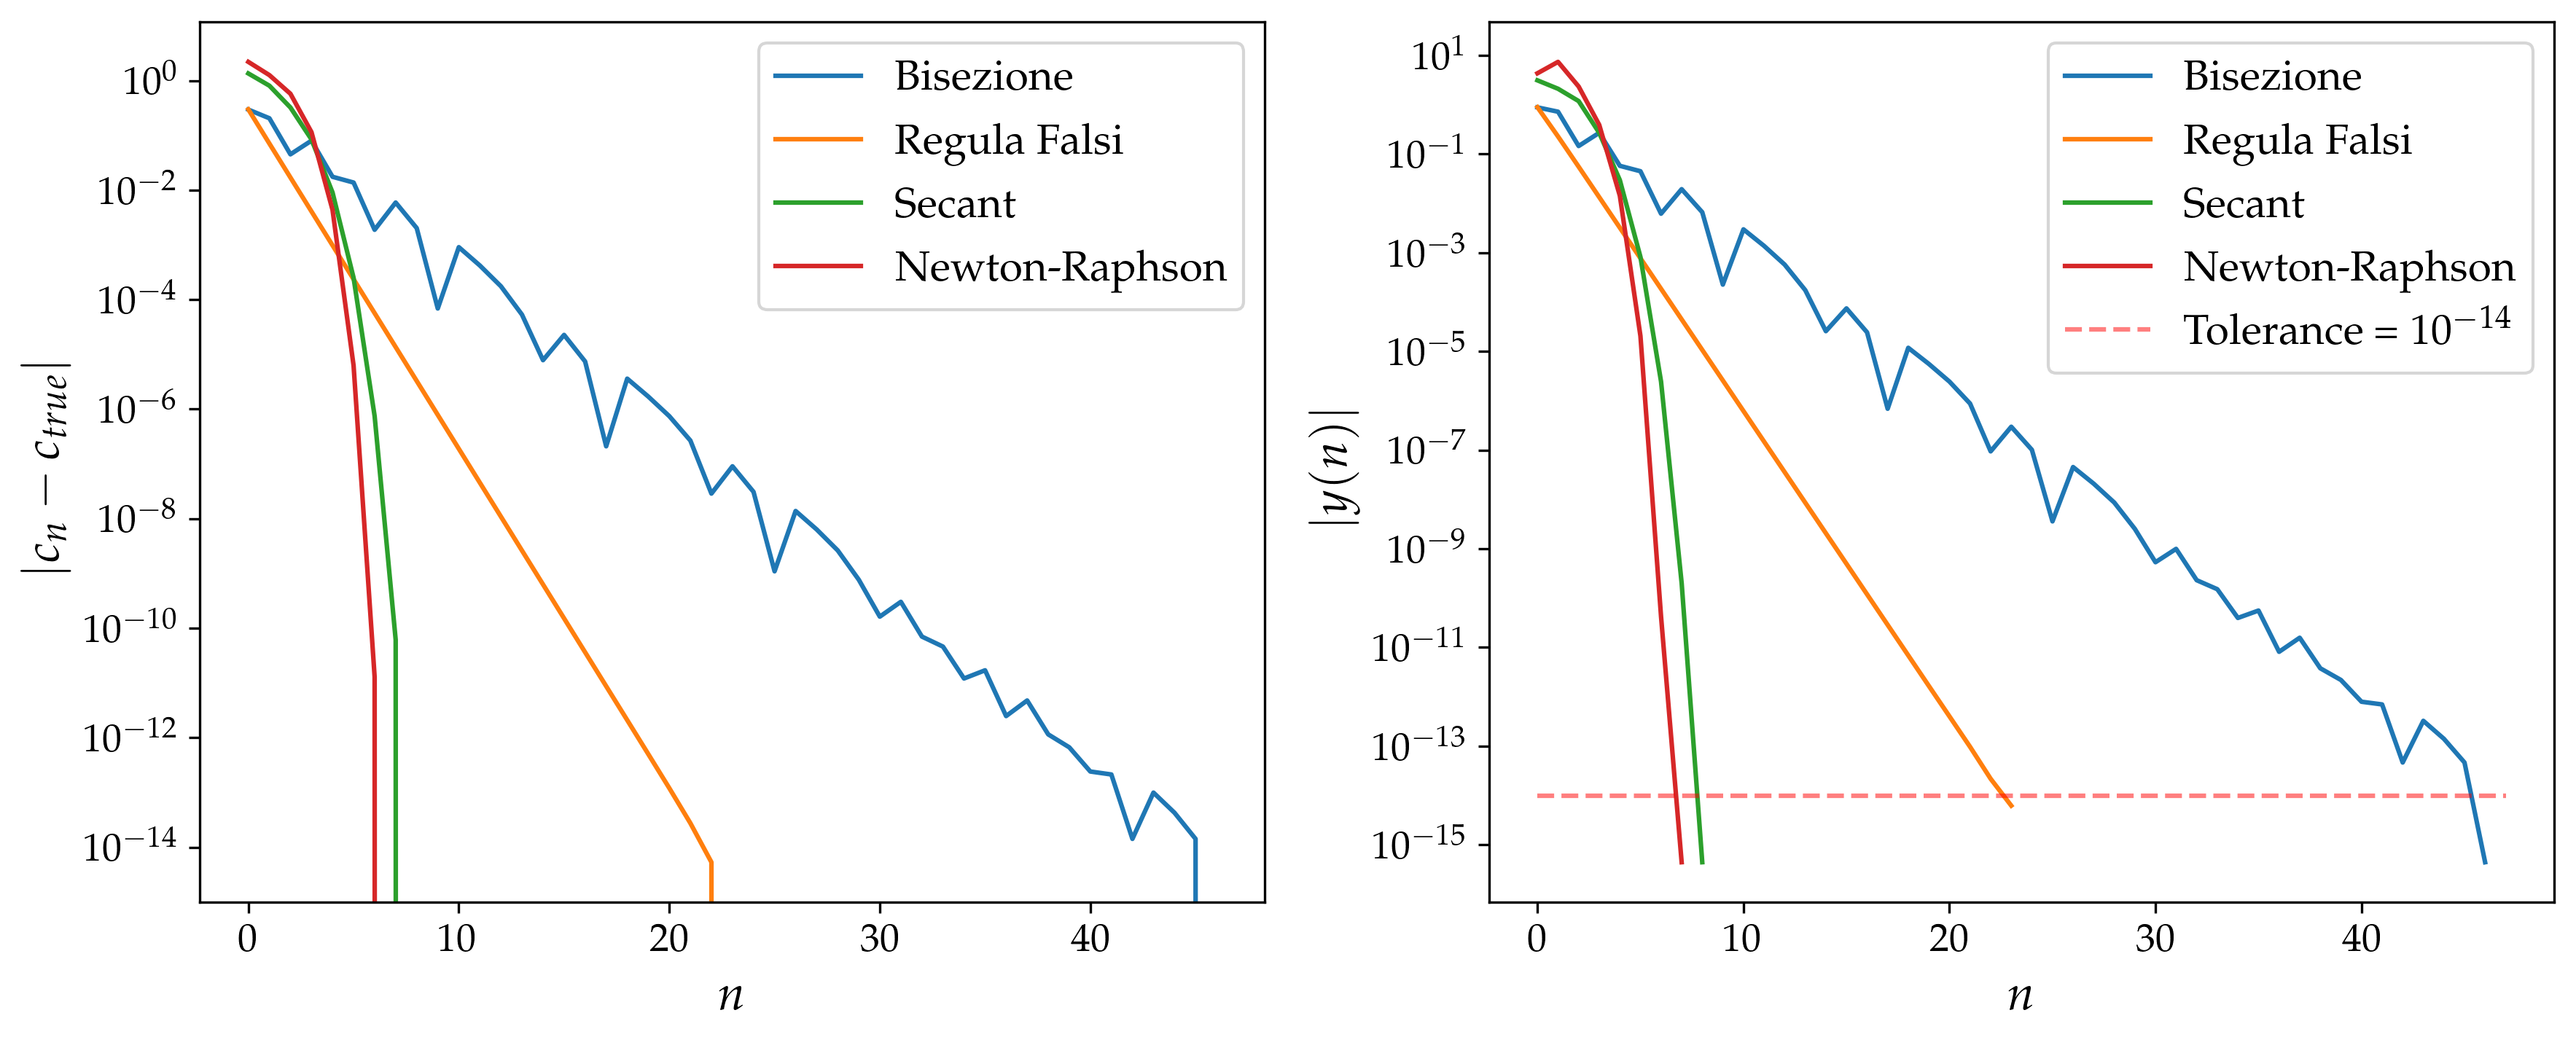

In [4]:
# Root research
a_bis, b_bis = (-9, -7)
c_bis, iter_bis, story_bis = bisec(f_even, a_bis, b_bis, optim=False, out_story=True)
c_reg, iter_reg, story_reg = bisec(f_even, a_bis, b_bis, optim=True, out_story=True)
c_Sec, iter_Sec, story_Sec = Secant_mth(f_even, -10, -6)
c_NR, iter_NR, story_NR = Newt_Rap(f_even, df_even, -9.9)

print('Bisection        c =', c_bis)
print('                 iters =', iter_bis)
print()
print('Regula Falsi     c =', c_reg)
print('                 iters =', iter_reg)
print()
print('Secant           c =', c_Sec)
print('                 iters =', iter_Sec)
print()
print('Newton-Raphson   c =', c_NR)
print('                 iters =', iter_NR)

iter_pack = [iter_bis, iter_reg, iter_Sec, iter_NR]
stories = [story_bis, story_reg, story_Sec, story_NR]
names = ['Bisezione', 'Regula Falsi', 'Secant', 'Newton-Raphson']
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
for i in range(4):
    n_iter = iter_pack[i]
    story = stories[i]

    xcoo = np.arange(n_iter)
    errx = abs(story - story[-1])
    erry = abs(np.array([f_even(ele) for ele in story]))
    ax1.plot(xcoo, errx, label=names[i])
    ax2.plot(xcoo, erry, label=names[i])
    
ax2.hlines(1e-14, 0, max(iter_pack), ls='--', color='r', alpha=0.5, label=r'Tolerance = $10^{-14}$')
ax1.set_xlabel(r'$n$')
ax2.set_xlabel(r'$n$')
ax1.set_ylabel(r'$|c_n - c_{true}|$')
ax2.set_ylabel(r'$|y(n)|$')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.savefig('plots/even_conv.png')
plt.show()

## **Proof of the convergence**

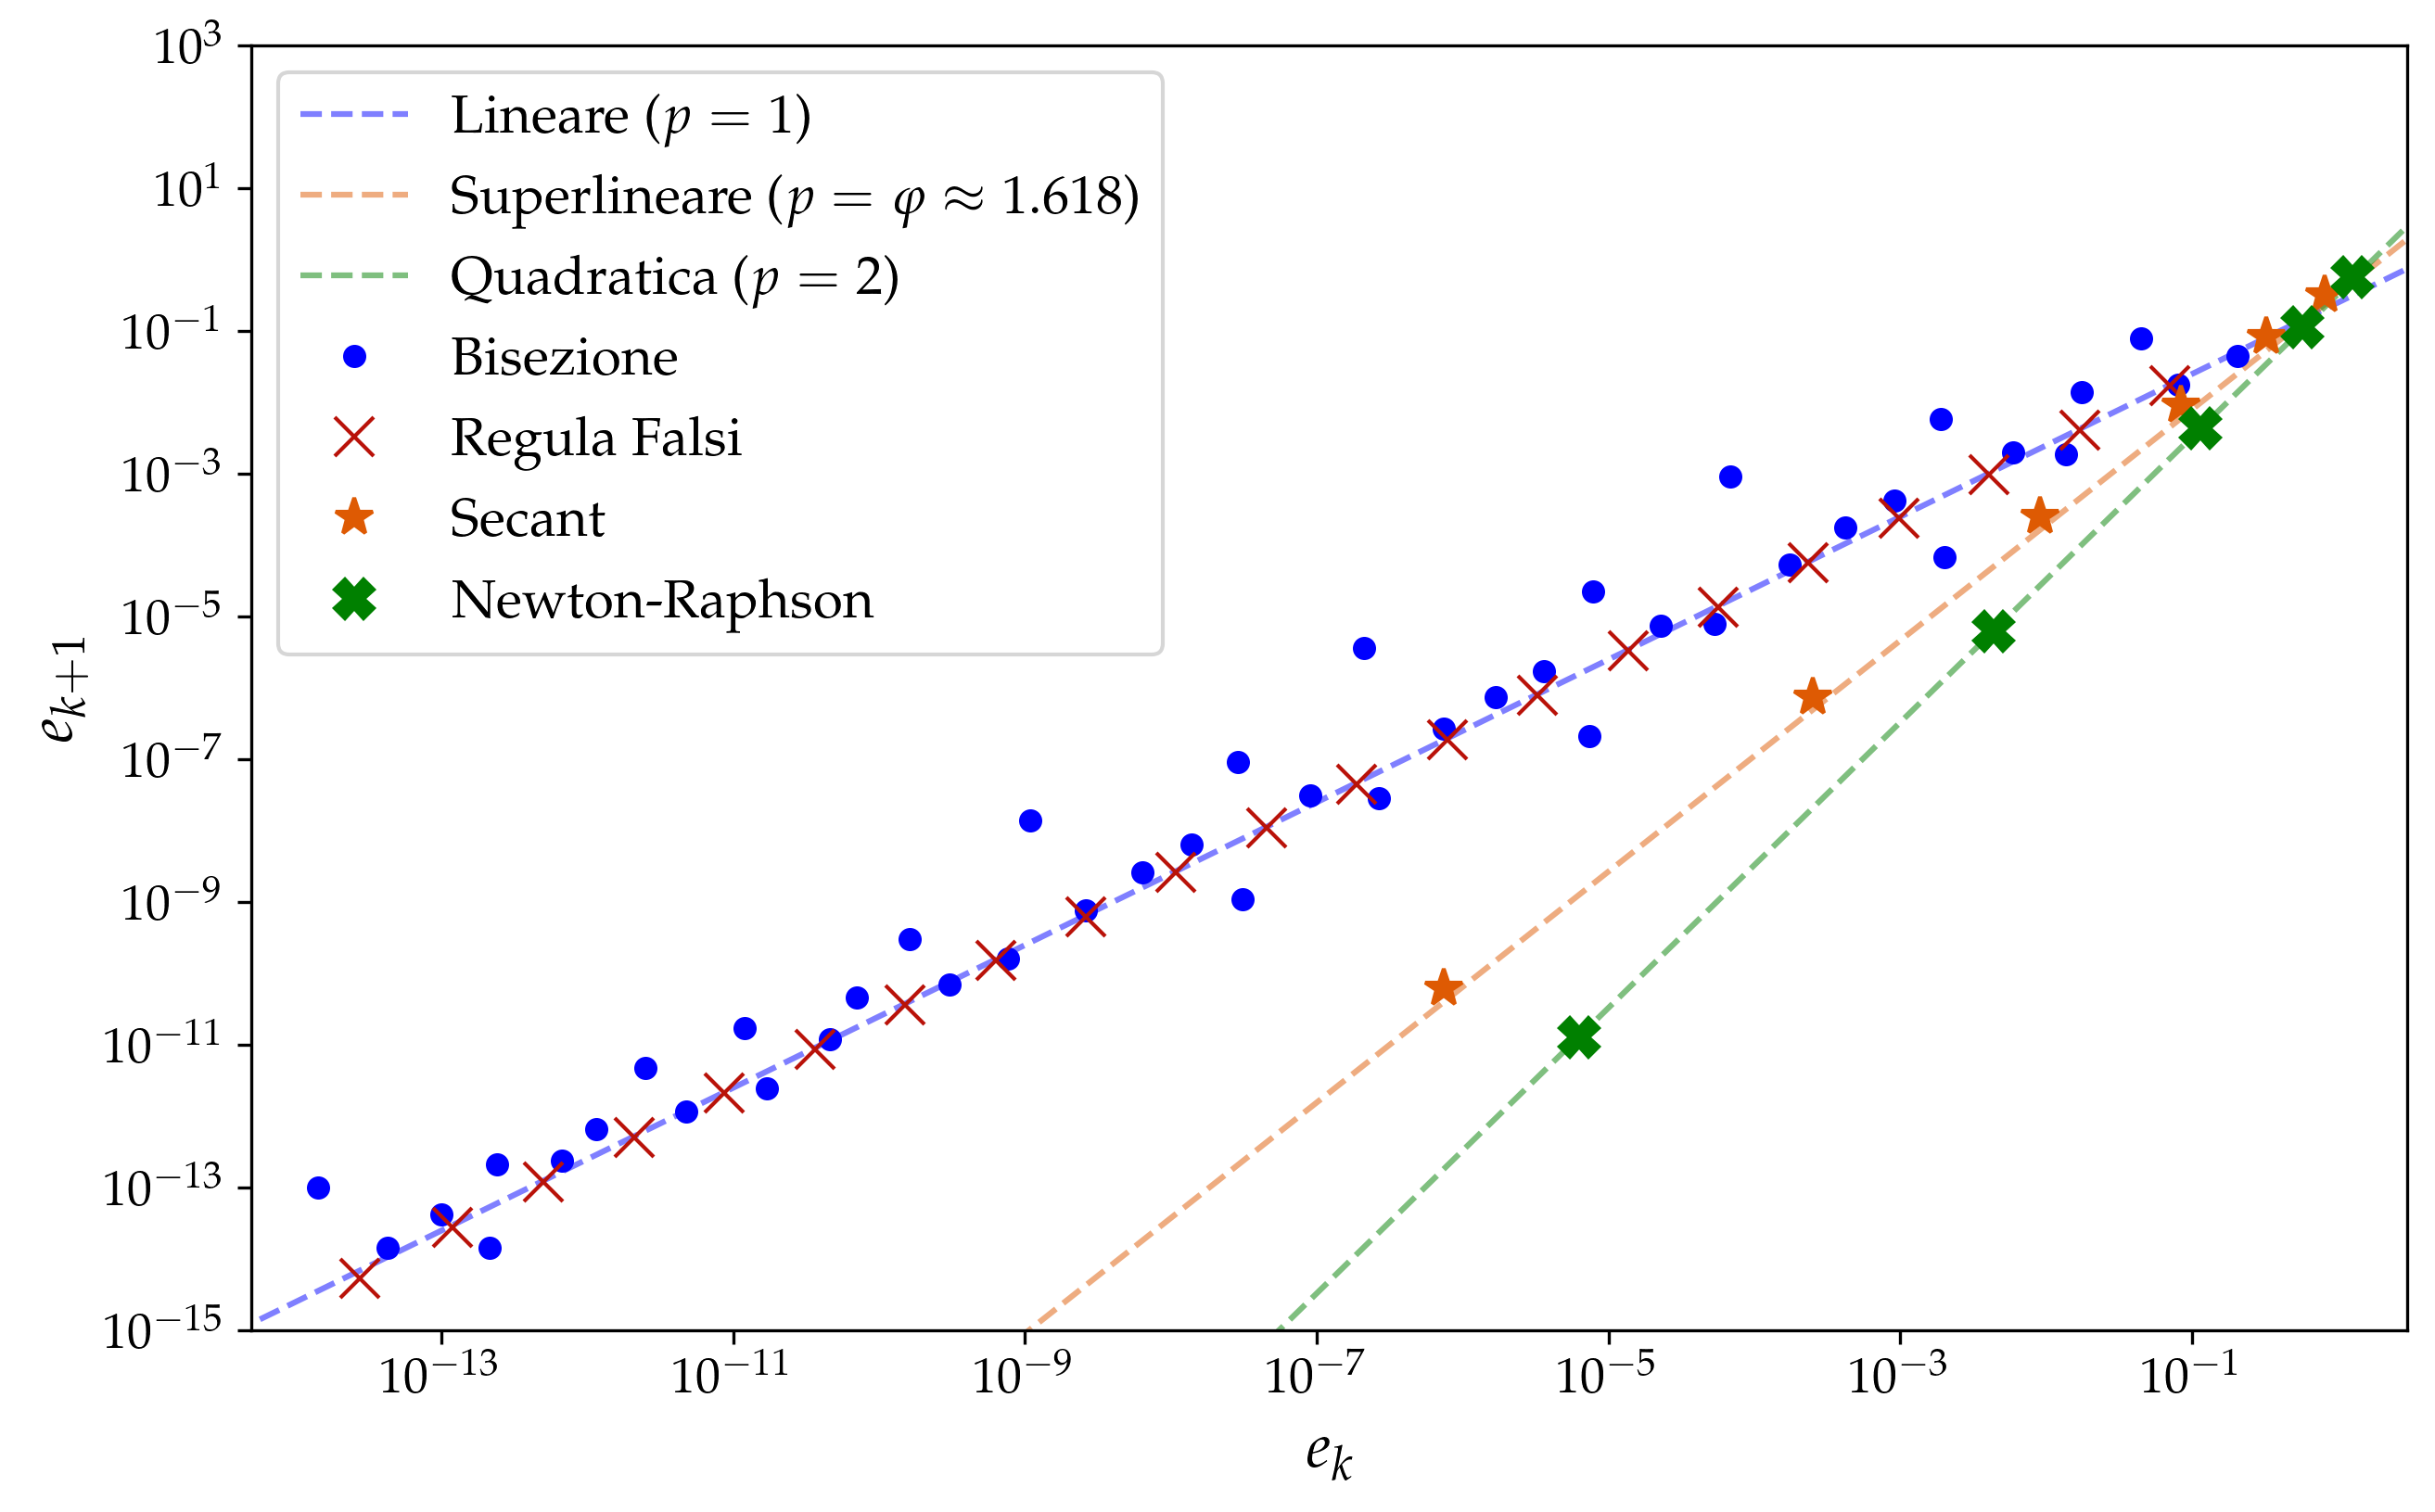

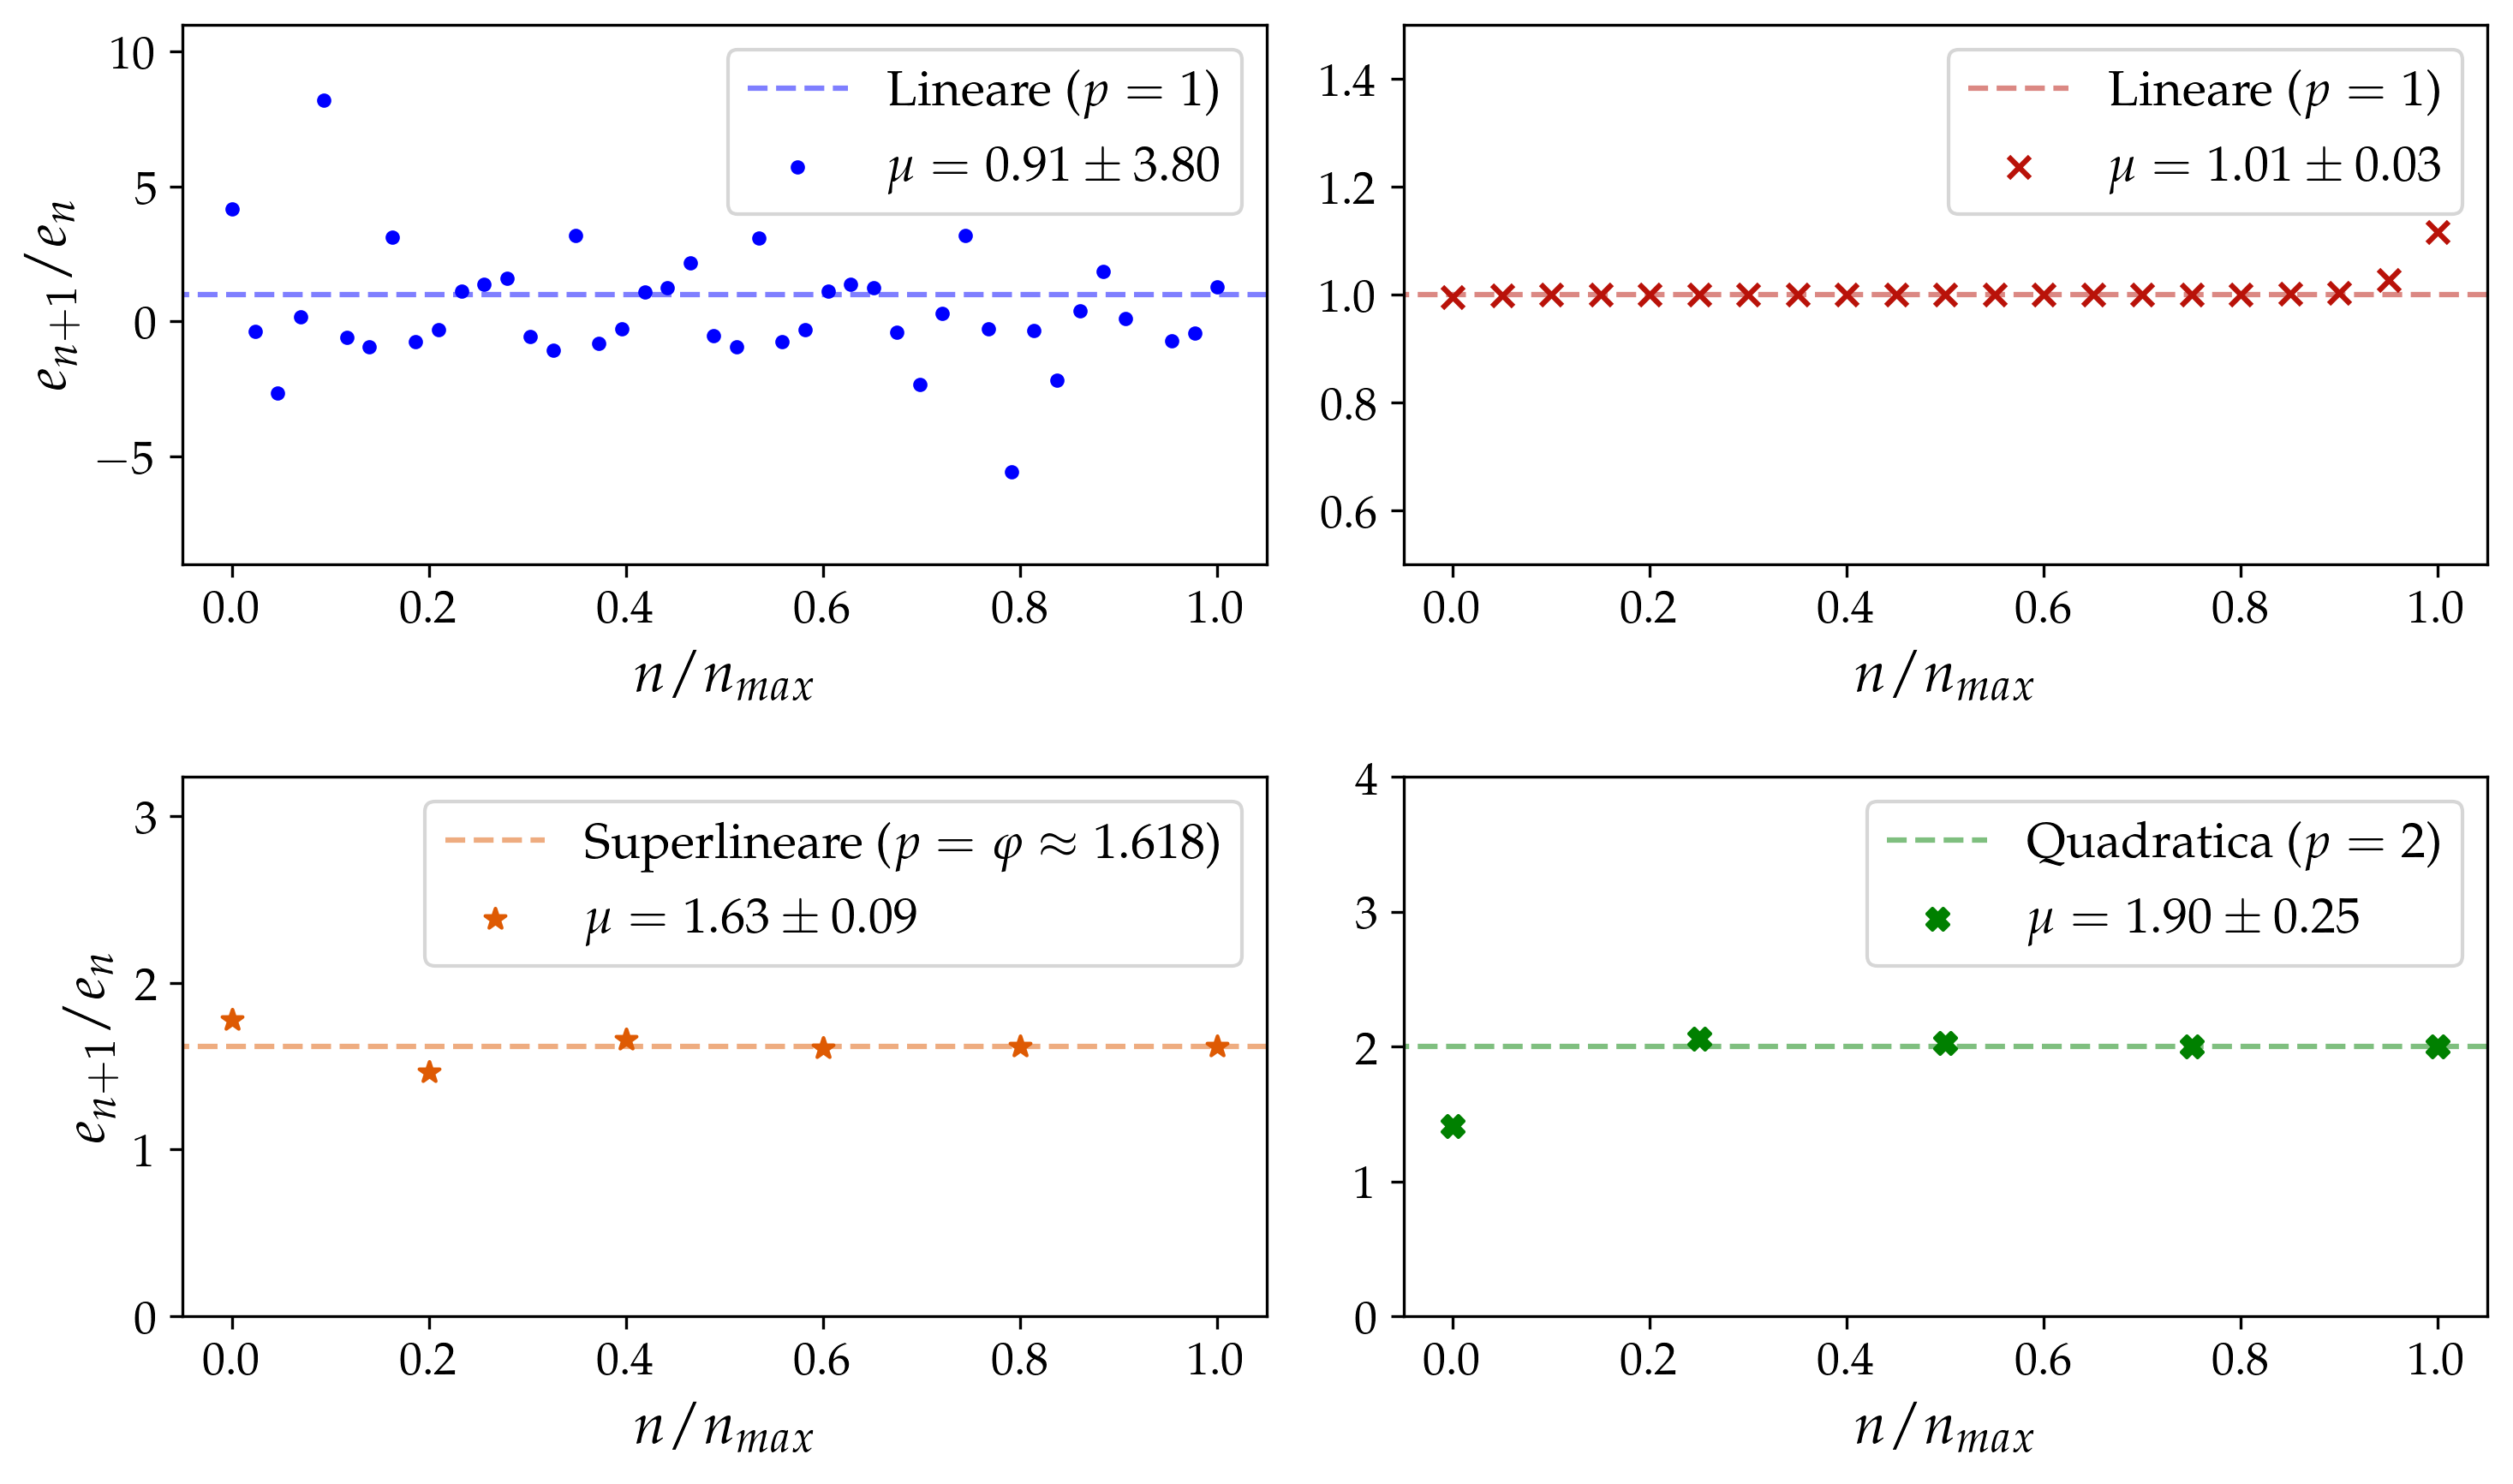

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 6))
fig_mul, axes = plt.subplots(2,2, figsize=(10, 6))
axes = axes.flatten()
ax2, ax5, ax3, ax4 = axes
min_err = 1e-15
max_err = 1000
phi = (1 + np.sqrt(5)) / 2

ax1.set_xlim(5e-15, 3)
ax1.set_ylim(bottom=min_err, top=max_err)

ax2.set_ylim(bottom=-9, top=11)
ax3.set_ylim(bottom=0, top=2*phi)
ax4.set_ylim(bottom=0, top=4)
ax5.set_ylim(bottom=0.5, top=1.5)
colors = ['blue',"#B91209", '#DE5A03', 'green']

x_ref = np.logspace(-15, 2, 10)

lin_k = 1/2**(b_bis - a_bis)
parab_coeff = 1/2 * d2f_even(c_NR)/df_even(c_NR) 

ax1.plot(x_ref, lin_k*x_ref, '--', color=colors[0], alpha=0.5, label=r'Lineare ($p=1$)')
ax1.plot(x_ref, parab_coeff*x_ref**phi, '--', color=colors[2], alpha=0.5, label=r'Superlineare ($p=\varphi\approx 1.618$)')
ax1.plot(x_ref, parab_coeff*x_ref**2, '--', color=colors[3], alpha=0.5, label=r'Quadratica ($p=2$)')
hxcoo = 10
ax2.hlines(1, -hxcoo, hxcoo, ls='--', label=r'Lineare ($p=1$)', color=colors[0], alpha=0.5)
ax5.hlines(1, -hxcoo, hxcoo, ls='--', label=r'Lineare ($p=1$)', color=colors[1], alpha=0.5)
ax3.hlines(phi, -hxcoo, hxcoo, ls='--', label=r'Superlineare ($p=\varphi\approx 1.618$)', color=colors[2], alpha=0.5)
ax4.hlines(2, -hxcoo, hxcoo, ls='--', label=r'Quadratica ($p=2$)', color=colors[3], alpha=0.5 )

for i in range(4):
    story = np.array(stories[i])
    # Calcoliamo l'errore come distanza dall'ultimo valore trovato (la radice)
    err = abs(story - story[-1])
    
    # Definiamo e_k (errore attuale) e e_{k+1} (errore successivo)
    # Escludiamo l'ultimo punto perché l'errore è zero (log non definito)
    ek_minus_1 = err[:-3] 
    ek = err[1:-2] 
    ek_plus_1 = err[2:-1] 

    pk = np.log(ek_plus_1/ek) / np.log(ek/ek_minus_1)
    Kk = ek_plus_1/(ek**pk)

    p_mean = np.mean(pk)
    p_std = np.std(pk)

    markers = ['.', 'x', '*', 'X']
    ax1.loglog(ek, ek_plus_1, marker=markers[i], color=colors[i], ls='', ms=10, label=names[i])
    n_coo = np.linspace(0, 1, len(pk))
    axes[i].scatter(n_coo, pk, marker=markers[i], color=colors[i], label=rf'$\mu = {p_mean:.2f} \pm {p_std:.2f}$')
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_xlabel(r'$n/n_{max}$')
    axes[i].legend()

ax1.set_xlabel(r'$e_k$')
ax1.set_ylabel(r'$e_{k+1}$')
ax1.legend()
axes[0].set_ylabel(r'$e_{n+1}/e_n$')
axes[2].set_ylabel(r'$e_{n+1}/e_n$')
plt.tight_layout()

fig.savefig('plots/scat_lines_even.png')
fig_mul.savefig('plots/single_scat_even.png')
plt.show()

## **Failing of Newton**

c_true = -7.705009250739082

start = -5.2
c = -7.7050092507390815
iters = 11

start = -5.133333333333334
c = -7.7050092507390815
iters = 12

start = -5.066666666666666
c = -7.705009250739082
iters = 17

start = -5.0
c = nan
iters = 8


<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(2)*sqrt(-E) + sqrt(2*E + 20)*tan((1/2)*sqrt(2*E + 20))
<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in sqrt
  return (1/2)*tan((1/2)*sqrt(2*E + 20))**2 + 1/2 + tan((1/2)*sqrt(2*E + 20))/sqrt(2*E + 20) - 1/2*sqrt(2)*sqrt(-E)/E
c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:154: RuntimeWarning: 
NaN detected at iteration 7 for x0 = -5.00
  warnings.warn(f'\nNaN detected at iteration {n_iter} for x0 = {x0:.2f}', RuntimeWarning)


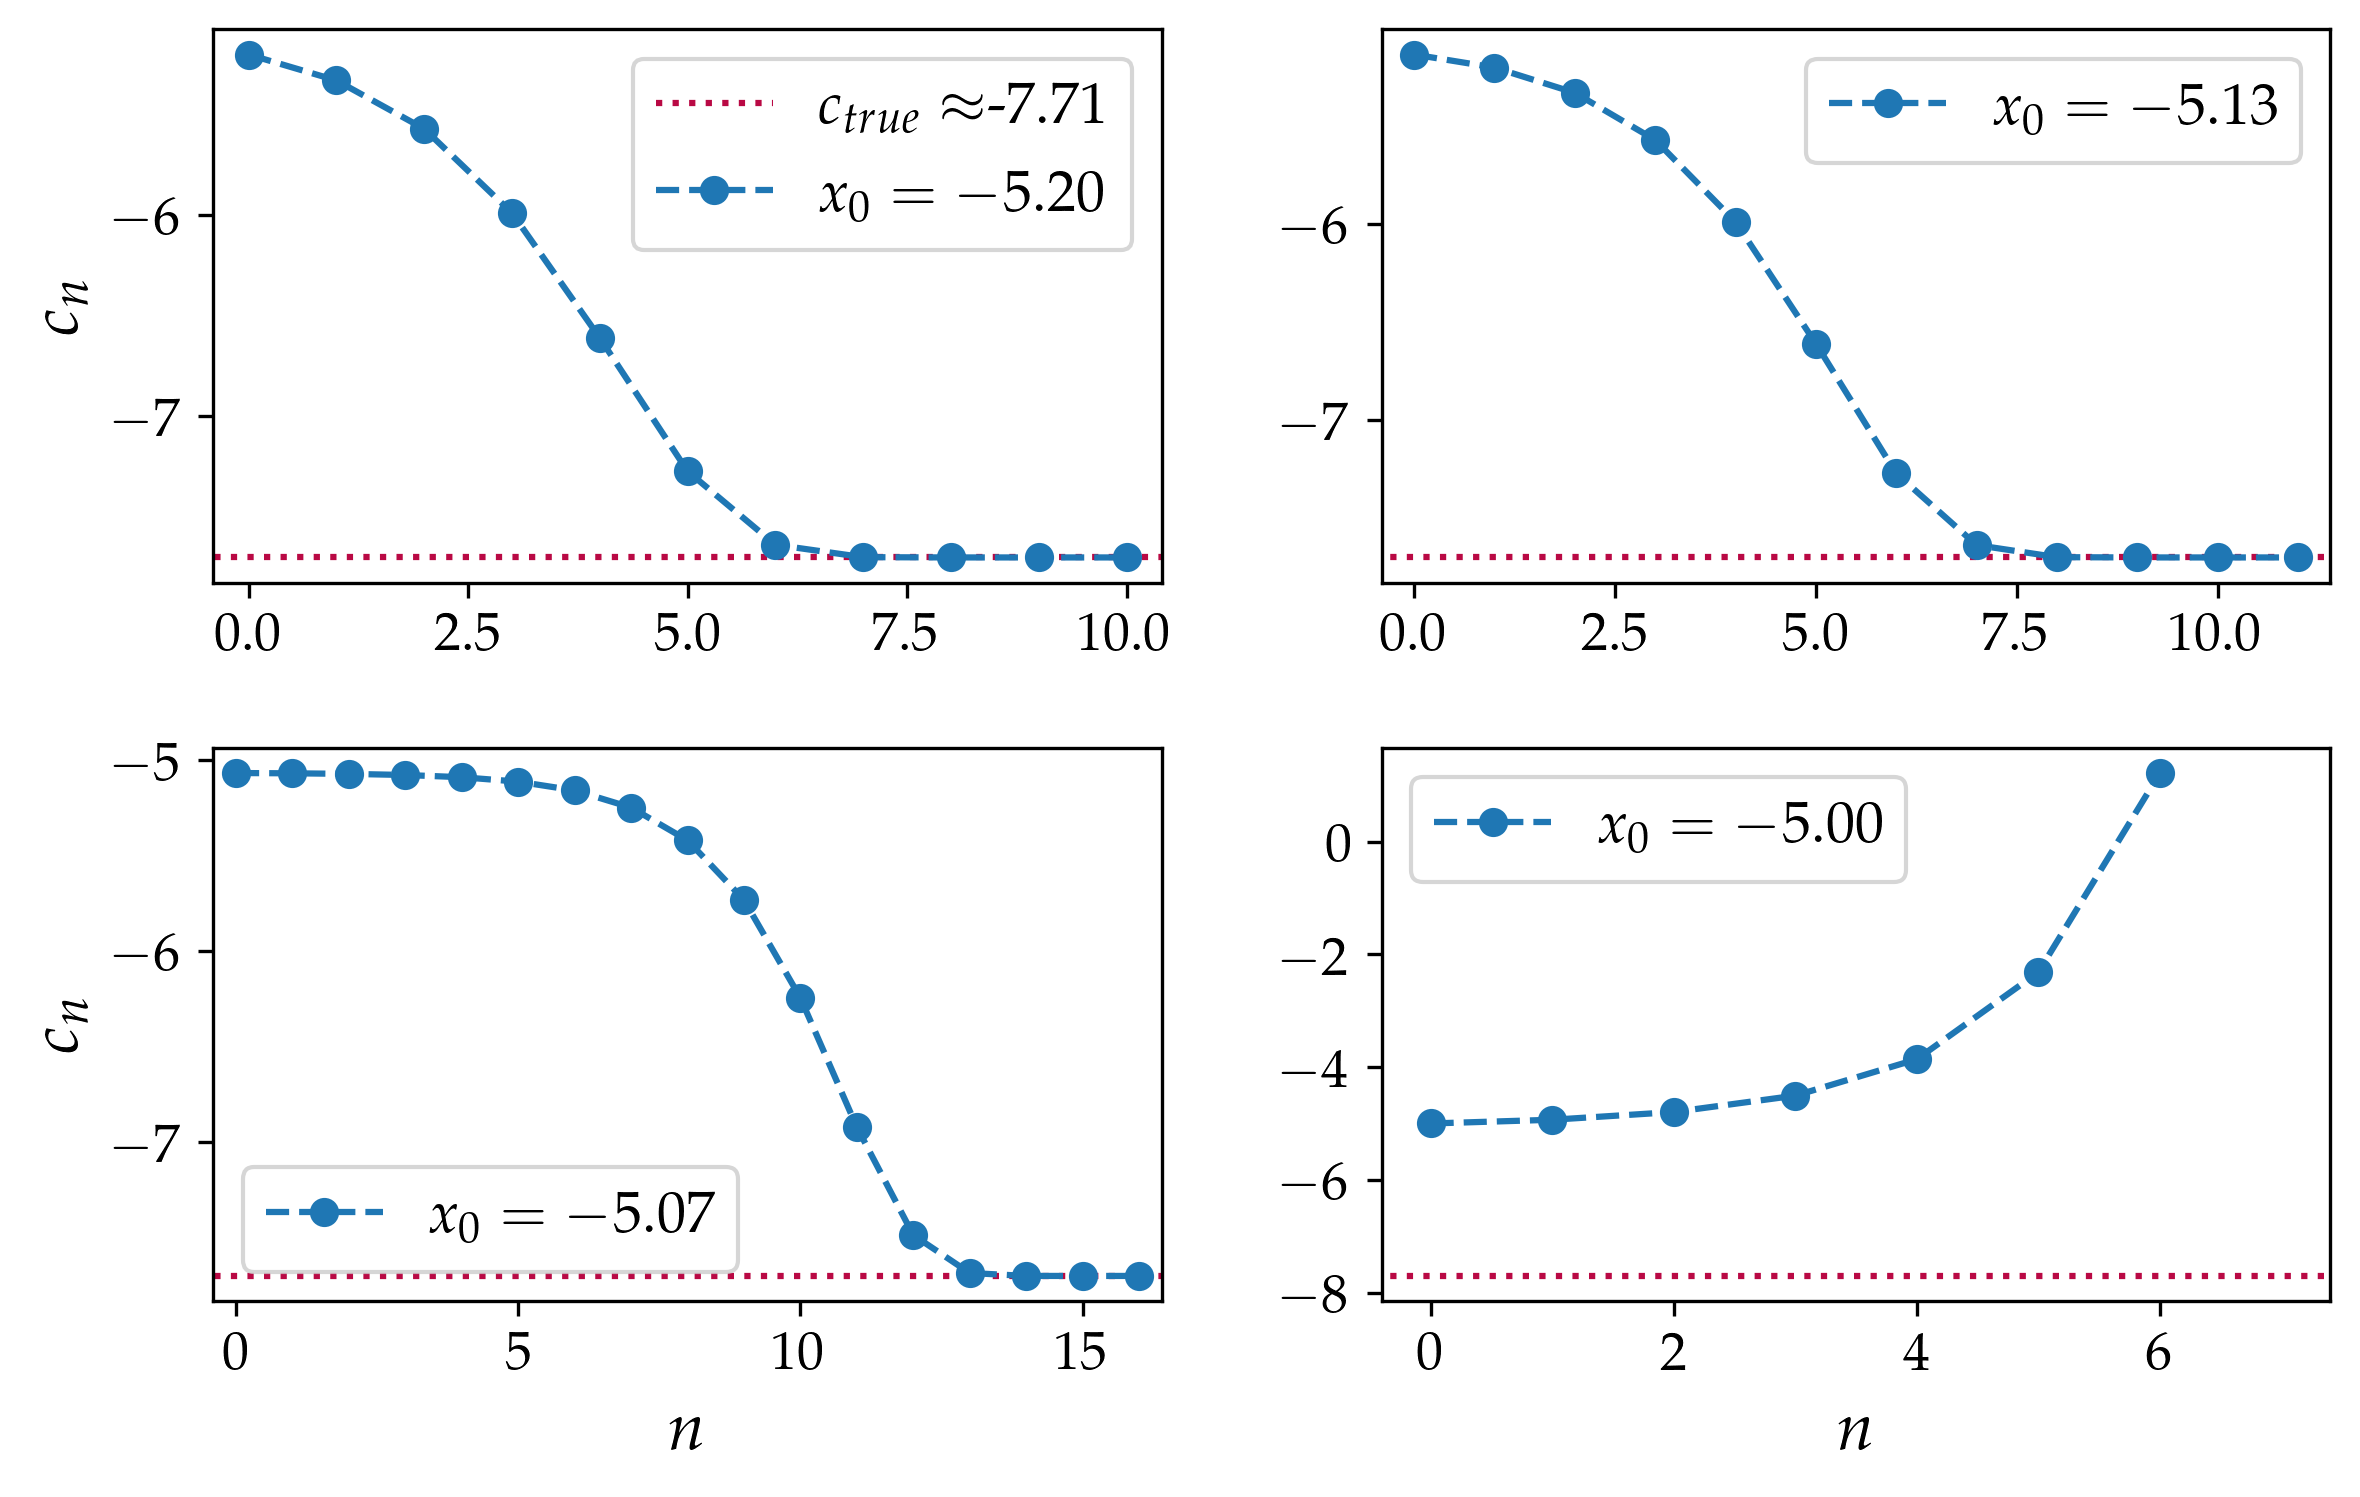

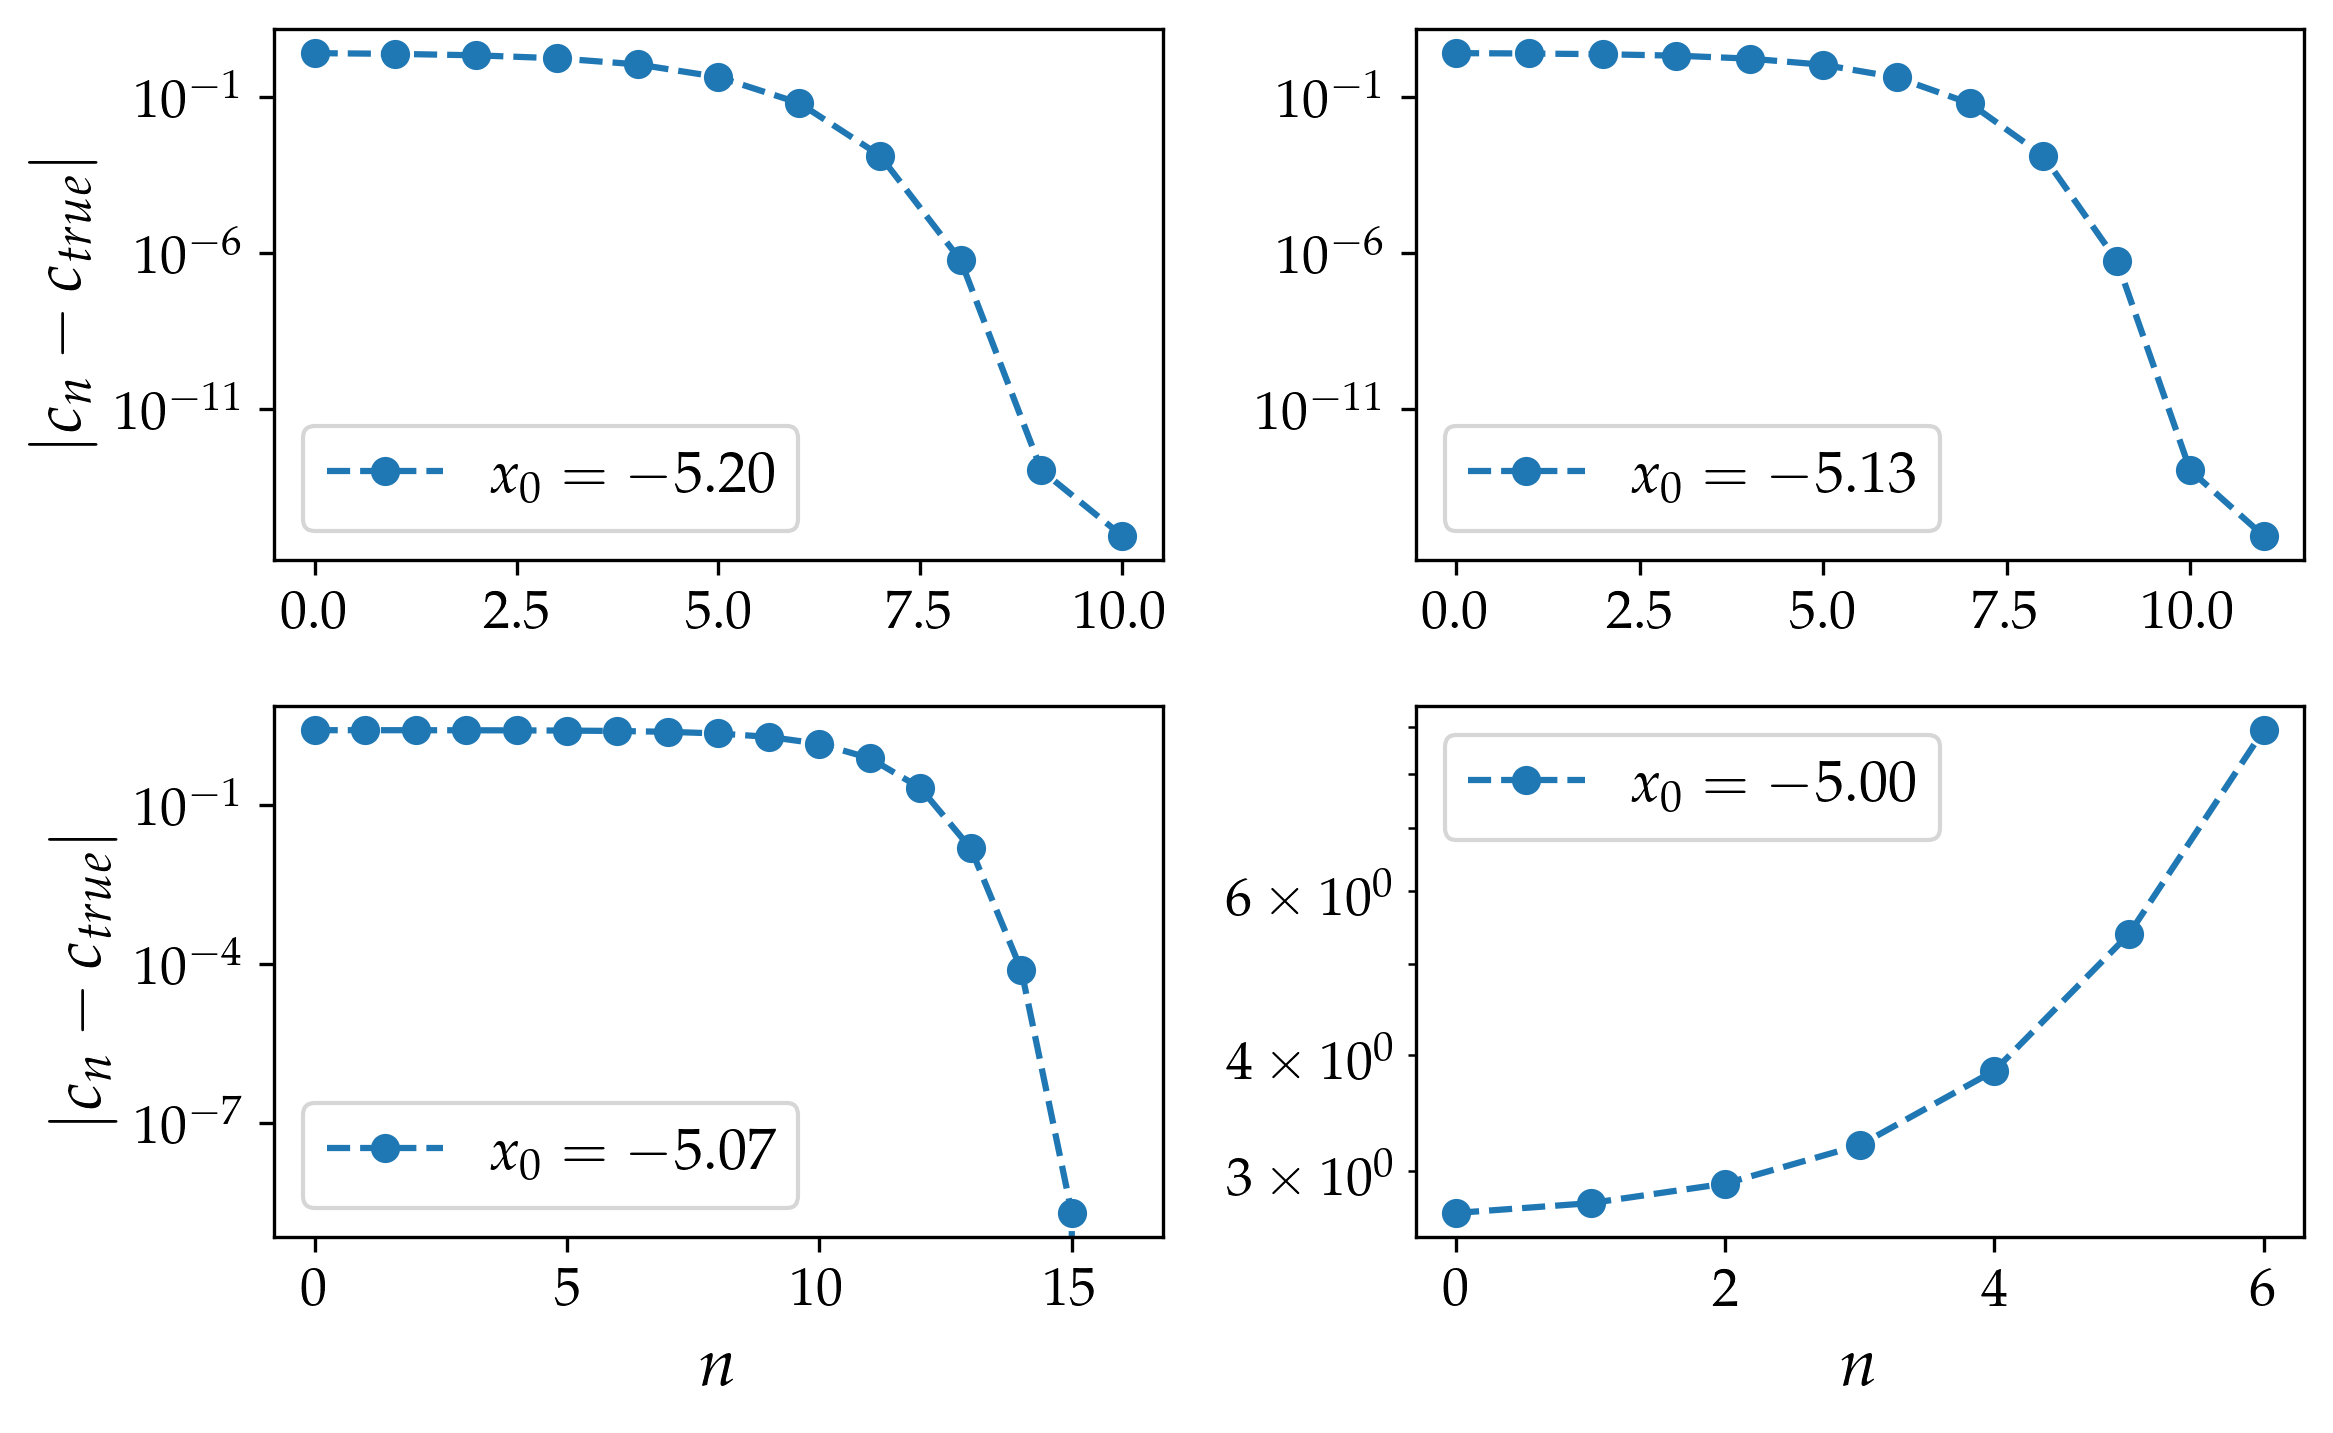

In [6]:
# Root research
C_TRUE, iter_true, story_true = Newt_Rap(f_even, df_even, -7)
print('c_true =', C_TRUE)

start_NR = np.linspace(-5.2,-5.0, 4)
fig_NR, ax_NR = plt.subplots(2,2, figsize=(8,5))
plt.tight_layout()
ax_flat = ax_NR.flatten()
fig_err, ax_err = plt.subplots(2,2, figsize=(8,5))
ax_err = ax_err.flatten()

for i in range(len(start_NR)):
    ax = ax_flat[i]
    ax1 = ax_err[i]
    start = start_NR[i]
    c_NR, iter_NR, story_NR = Newt_Rap(f_even, df_even, start)
    c_err = np.abs(story_NR - C_TRUE)

    print('\nstart =', start)
    print('c =', c_NR)
    print('iters =', iter_NR)

    xcoo = np.arange(iter_NR)
    if i == 0:
        ax.hlines(C_TRUE, -50, 50, ls=':', color="#B90944", label=r'$c_{true} \approx $' +f'{C_TRUE:.2f}')
    else:
        ax.hlines(C_TRUE, -50, 50, ls=':', color="#B90944")
    ax.plot(xcoo, story_NR, marker='o', ls='--', label=rf'$x_{0} = {start:.2f}$')
    ax1.plot(xcoo, c_err, marker='o', ls='--', label=rf'$x_{0} = {start:.2f}$')
    
    ax.set_xlim(-0.4, iter_NR-0.6)
    ax1.set_yscale('log')
    ax.legend()
    ax1.legend()
ax_flat[2].set_xlabel(r'$n$')
ax_flat[3].set_xlabel(r'$n$')
ax_flat[0].set_ylabel(r'$c_n$')
ax_flat[2].set_ylabel(r'$c_n$')

ax_err[2].set_xlabel(r'$n$')
ax_err[3].set_xlabel(r'$n$')
ax_err[0].set_ylabel(r'$|c_n - c_{true}|$')
ax_err[2].set_ylabel(r'$|c_n - c_{true}|$')
plt.tight_layout()

fig_NR.savefig('plots/cn_fail.png')
fig_err.savefig('plots/errn_fail.png')
plt.show()


## **Odd function roots**

<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in divide
  return sqrt(2)*sqrt(-E) + sqrt(2*E + 20)/tan((1/2)*sqrt(2*E + 20))
<lambdifygenerated-5>:2: RuntimeWarning: divide by zero encountered in divide
  return -1/2*(tan((1/2)*sqrt(2*E + 20))**2 + 1)/tan((1/2)*sqrt(2*E + 20))**2 + 1/(sqrt(2*E + 20)*tan((1/2)*sqrt(2*E + 20))) + (1/2)*sqrt(2)*sqrt(-E)/E
<lambdifygenerated-5>:2: RuntimeWarning: invalid value encountered in add
  return -1/2*(tan((1/2)*sqrt(2*E + 20))**2 + 1)/tan((1/2)*sqrt(2*E + 20))**2 + 1/(sqrt(2*E + 20)*tan((1/2)*sqrt(2*E + 20))) + (1/2)*sqrt(2)*sqrt(-E)/E
<lambdifygenerated-5>:2: RuntimeWarning: invalid value encountered in divide
  return -1/2*(tan((1/2)*sqrt(2*E + 20))**2 + 1)/tan((1/2)*sqrt(2*E + 20))**2 + 1/(sqrt(2*E + 20)*tan((1/2)*sqrt(2*E + 20))) + (1/2)*sqrt(2)*sqrt(-E)/E


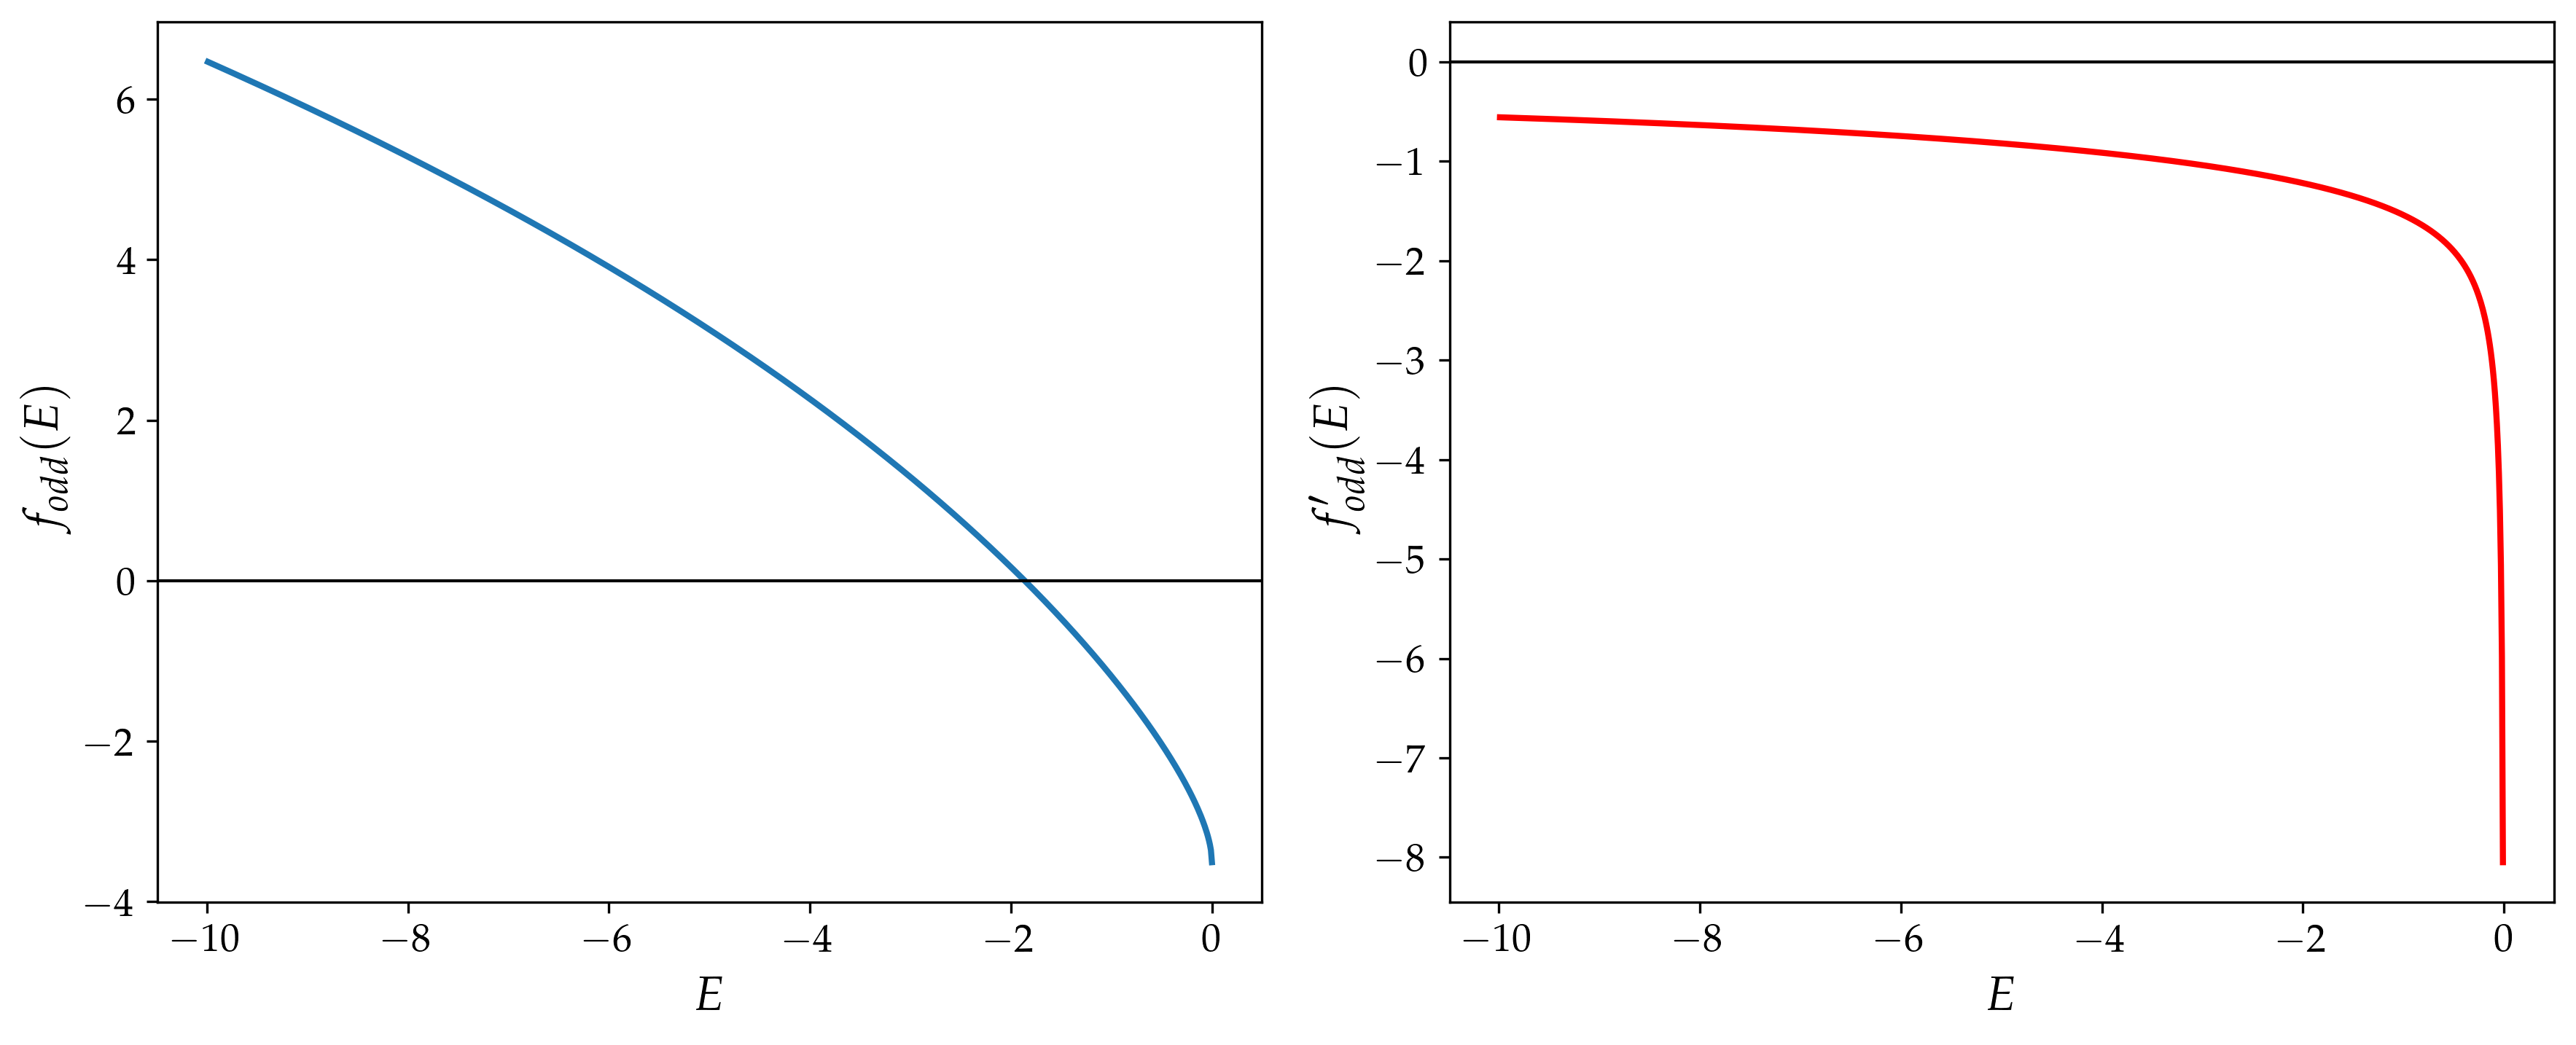

In [7]:
E_coo = np.linspace(-10, 0, 1000)
f_odd_E = f_odd(E_coo)
df_odd_E = df_odd(E_coo)

soglia = 1e5
f_odd_E_clean = np.where(np.abs(f_odd_E) > soglia, np.nan, f_odd_E)
df_odd_E_clean = np.where(np.abs(df_odd_E) > soglia, np.nan, df_odd_E)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax1.plot(E_coo, f_odd_E_clean, lw=2)
ax1.axhline(0, color='black', lw=1)
ax1.set_ylabel(r'$f_{odd}(E)$')
ax1.set_xlabel(r'$E$')

ax2.plot(E_coo, df_odd_E_clean, lw=2, color='red')
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel(r"$f'_{odd}(E)$")
ax2.set_xlabel(r'$E$')

plt.tight_layout()
plt.savefig('plots/f_odd.png')
plt.show()


Bisection        c = -1.8628522388353397
                 iters = 46

Regula Falsi     c = -1.862852238835343
                 iters = 19

Secant           c = -1.86285223883534
                 iters = 6

Newton-Raphson   c = -1.8628522388353395
                 iters = 7


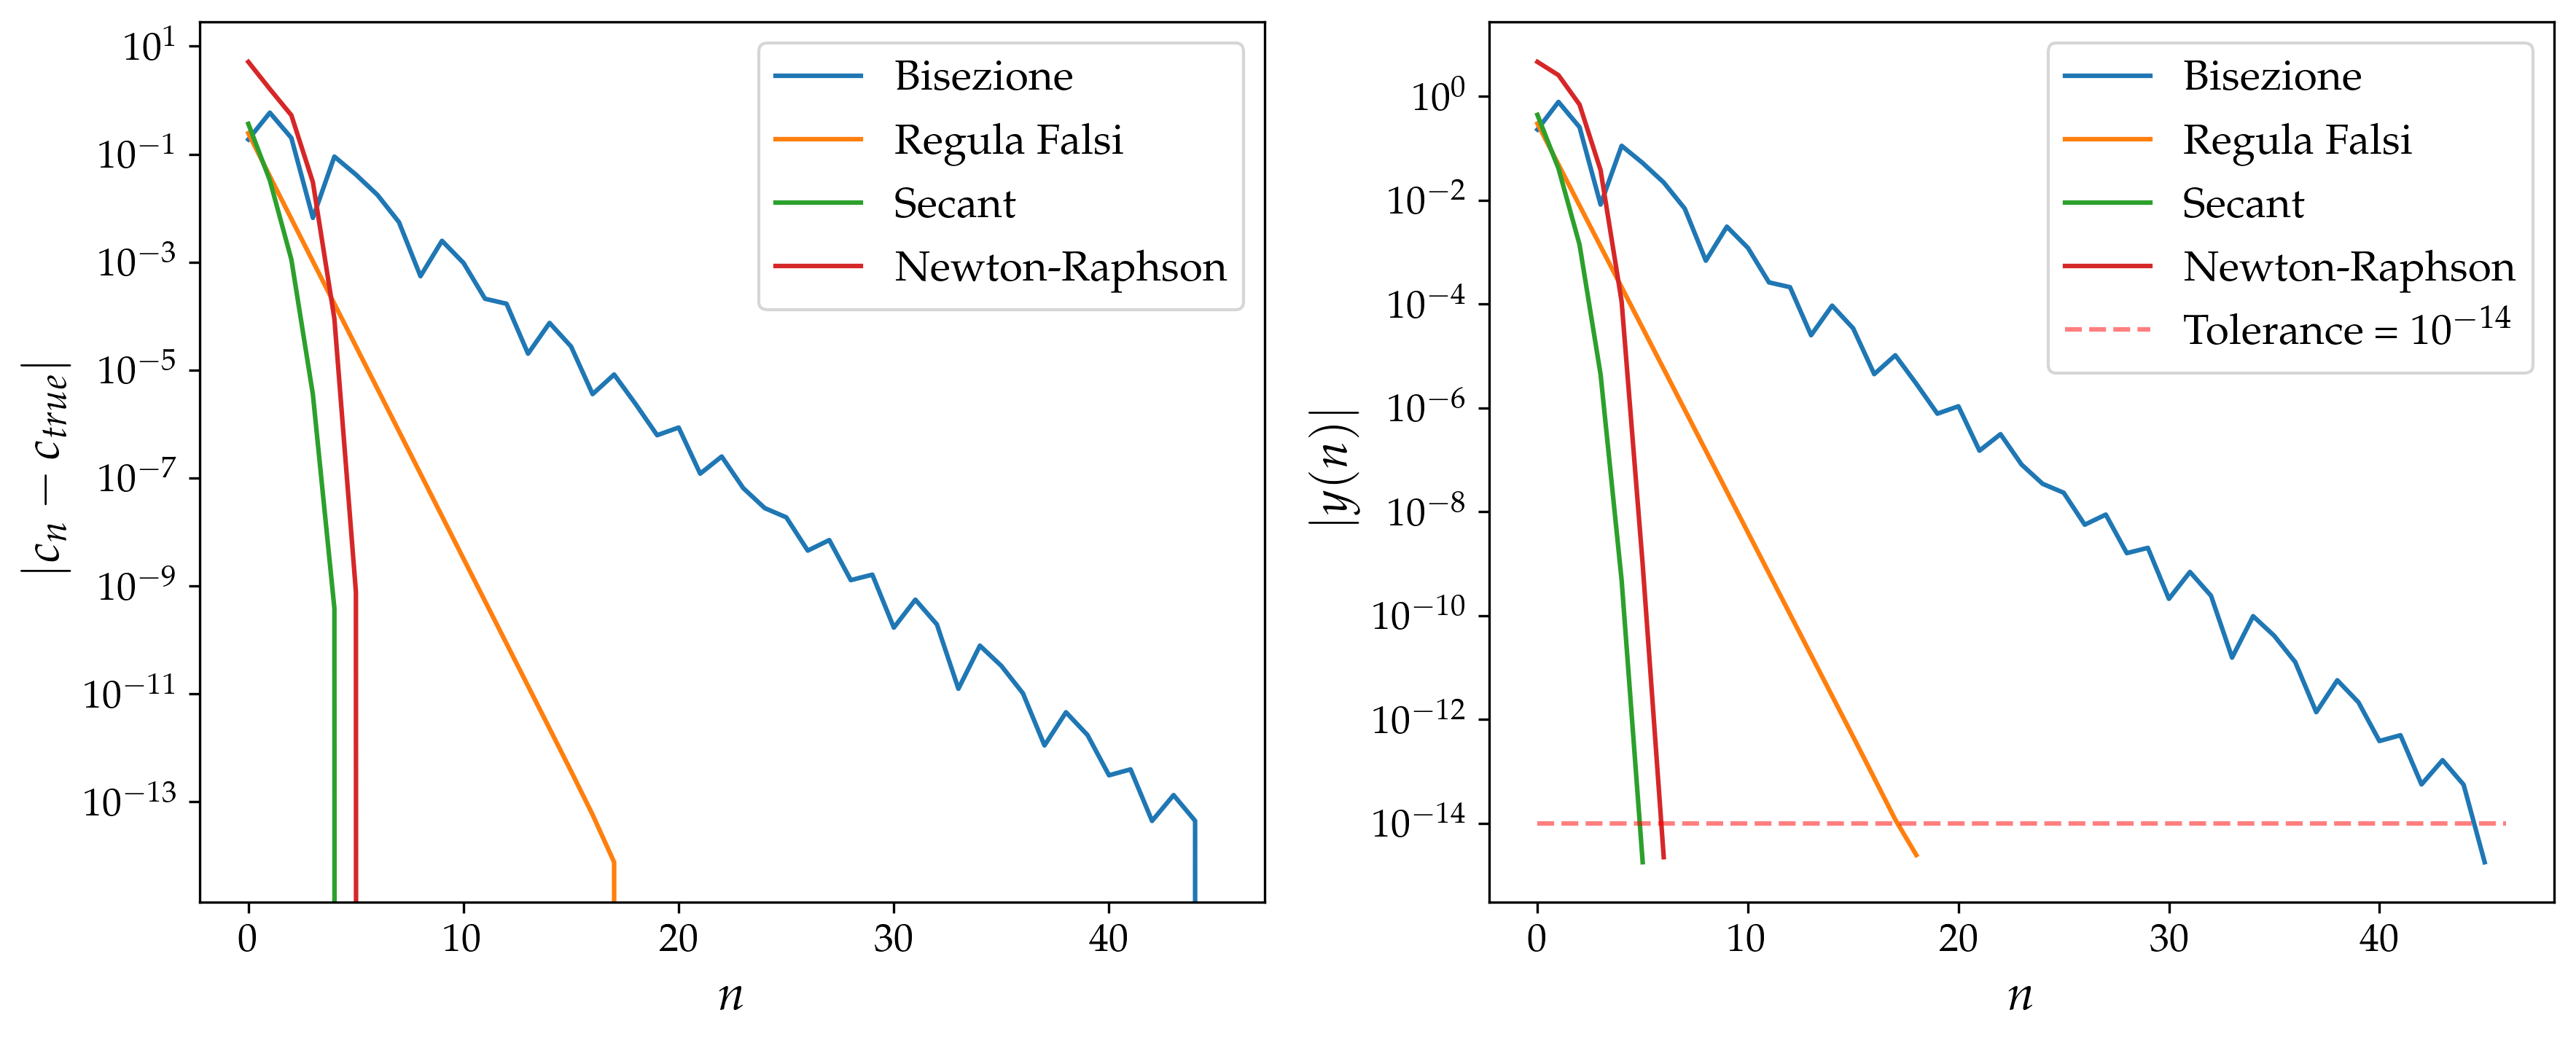

In [8]:
# Root research
a_bis, b_bis = (-3.6, -0.5)
a, b = (-7, 0.1)
c_bis, iter_bis, story_bis = bisec(f_odd, a_bis, b_bis, optim=False, out_story=True)
c_reg, iter_reg, story_reg = bisec(f_odd, a_bis, b_bis, optim=True, out_story=True)
c_Sec, iter_Sec, story_Sec = Secant_mth(f_odd, a, -1)
c_NR, iter_NR, story_NR = Newt_Rap(f_odd, df_odd, a)

print('Bisection        c =', c_bis)
print('                 iters =', iter_bis)
print()
print('Regula Falsi     c =', c_reg)
print('                 iters =', iter_reg)
print()
print('Secant           c =', c_Sec)
print('                 iters =', iter_Sec)
print()
print('Newton-Raphson   c =', c_NR)
print('                 iters =', iter_NR)

iter_pack = [iter_bis, iter_reg, iter_Sec, iter_NR]
stories = [story_bis, story_reg, story_Sec, story_NR]
names = ['Bisezione', 'Regula Falsi', 'Secant', 'Newton-Raphson']
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
for i in range(4):
    n_iter = iter_pack[i]
    story = stories[i]

    xcoo = np.arange(n_iter)
    errx = abs(story - story[-1])
    erry = abs(np.array([f_odd(ele) for ele in story]))
    ax1.plot(xcoo, errx, label=names[i])
    ax2.plot(xcoo, erry, label=names[i])
    
ax2.hlines(1e-14, 0, max(iter_pack), ls='--', color='r', alpha=0.5, label=r'Tolerance = $10^{-14}$')
ax1.set_xlabel(r'$n$')
ax2.set_xlabel(r'$n$')
ax1.set_ylabel(r'$|c_n - c_{true}|$')
ax2.set_ylabel(r'$|y(n)|$')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.savefig('plots/odd_conv.png')
plt.show()

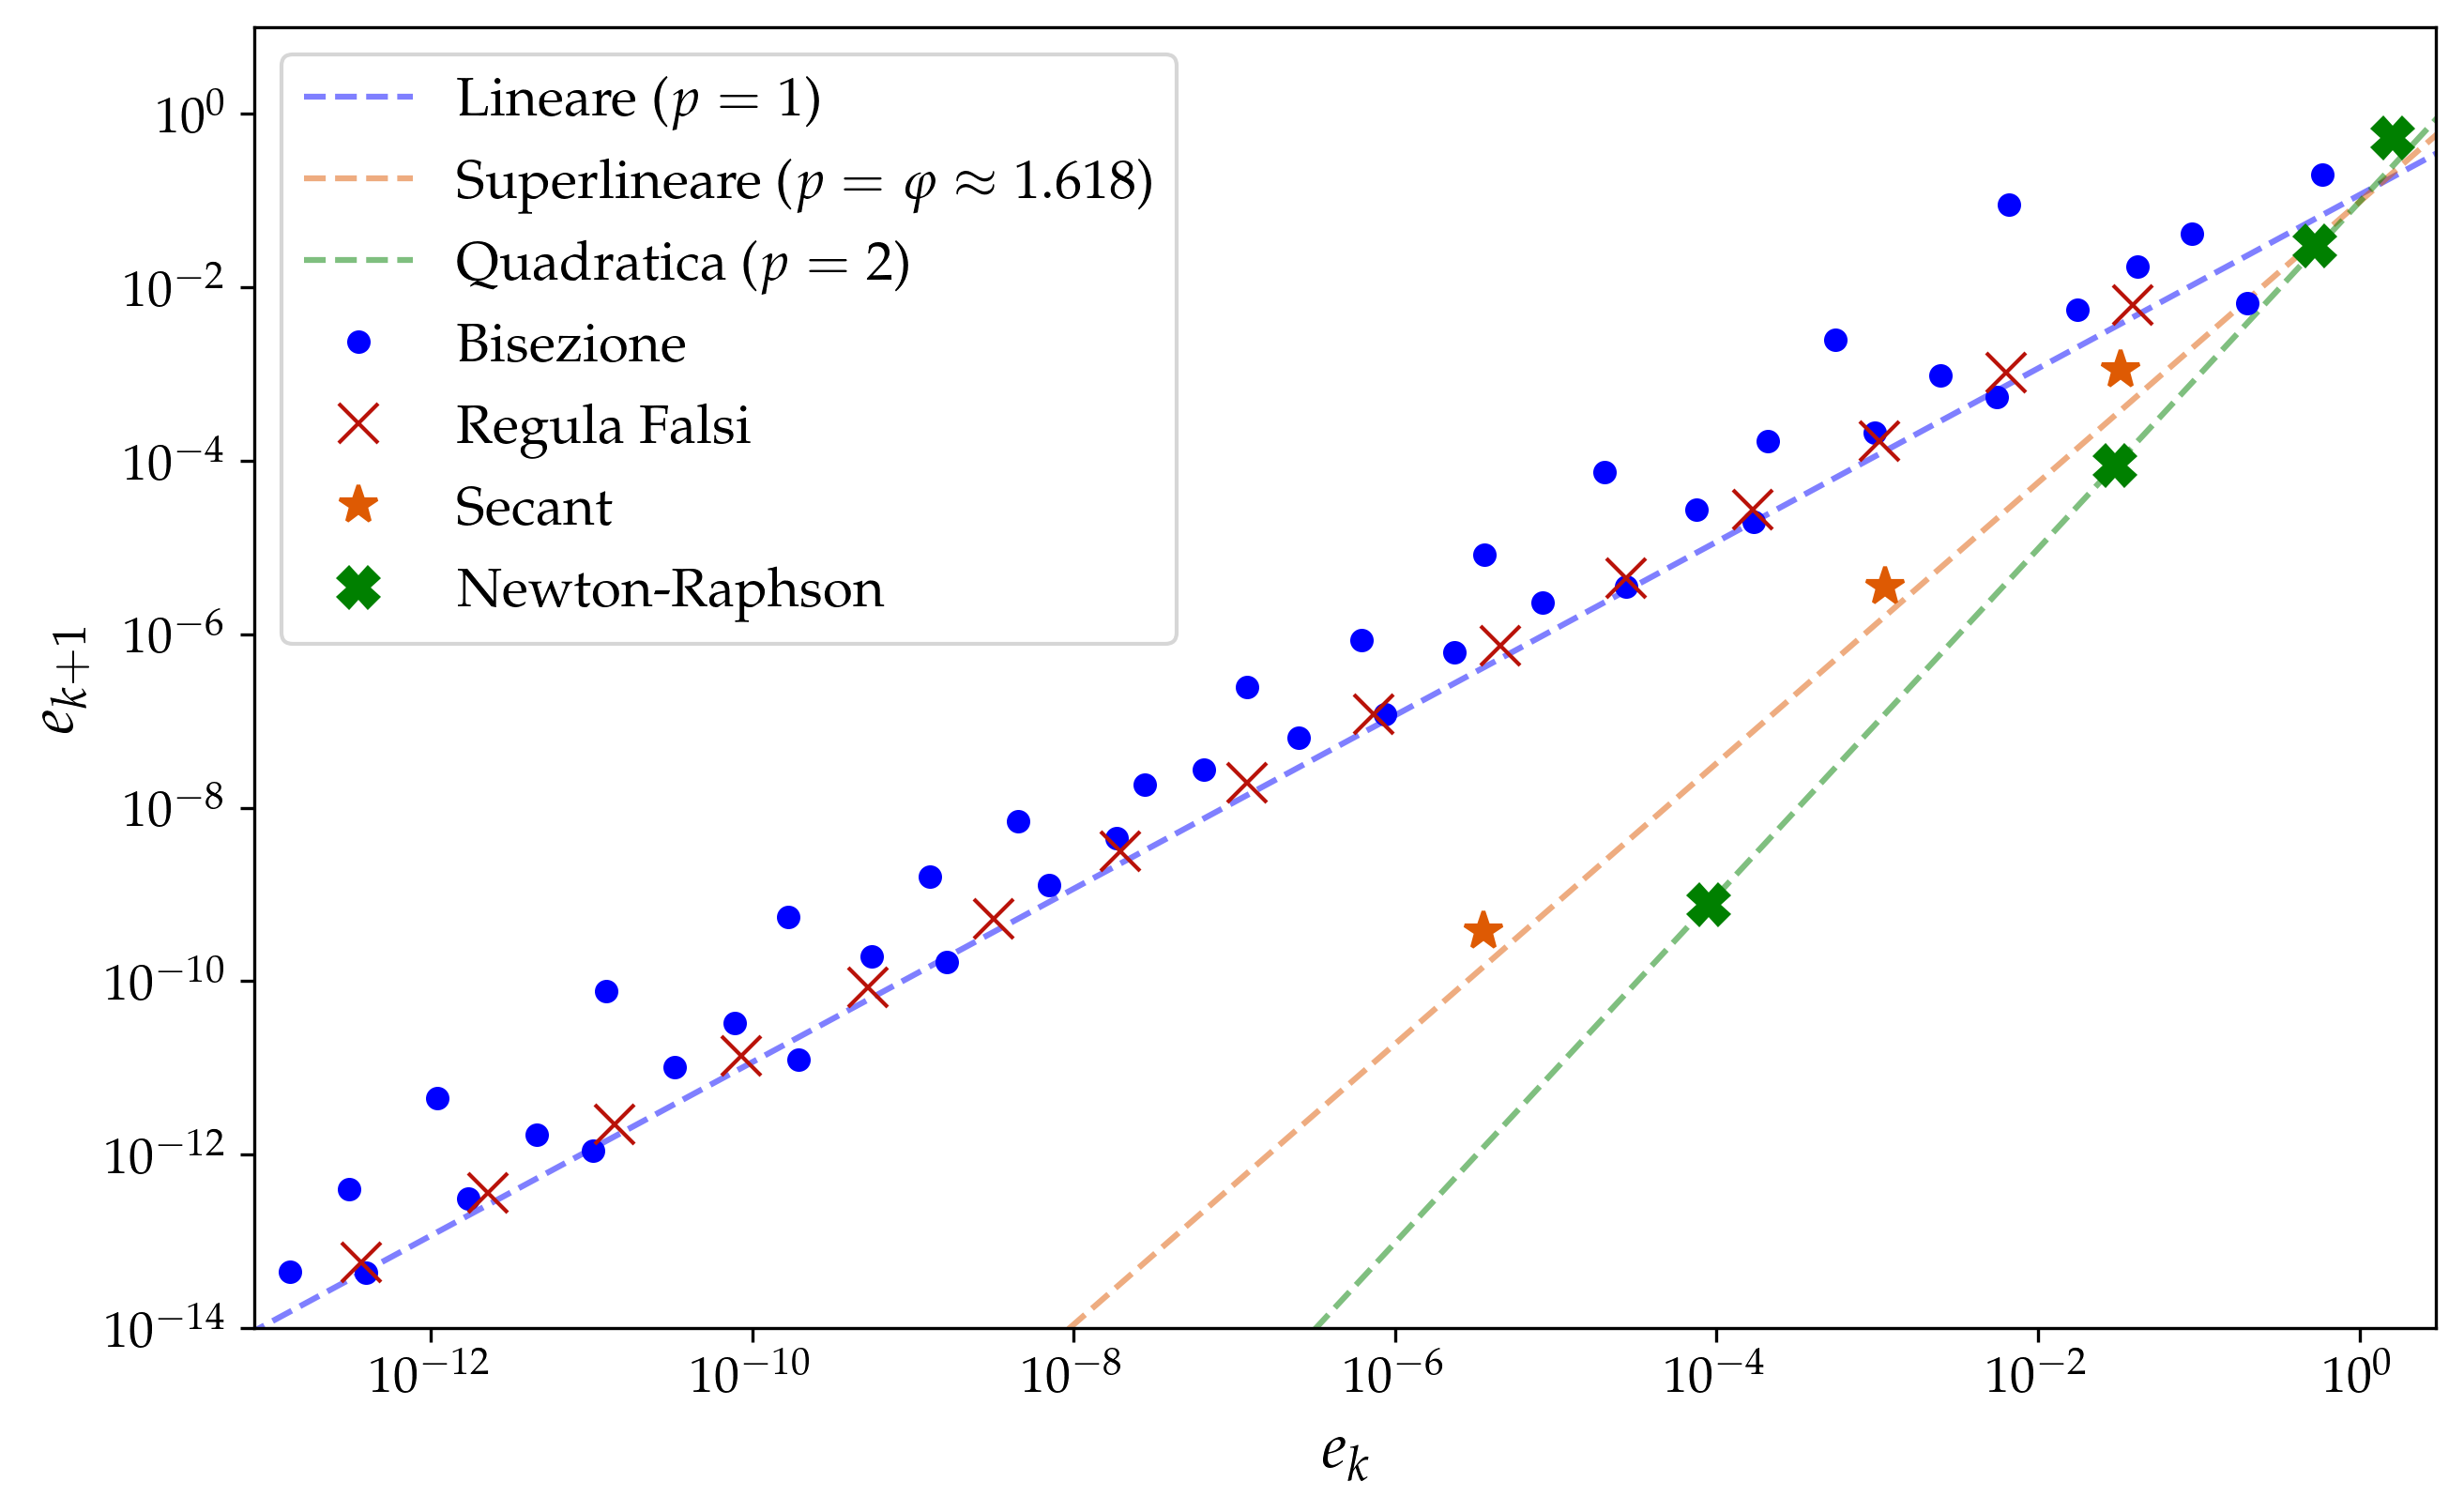

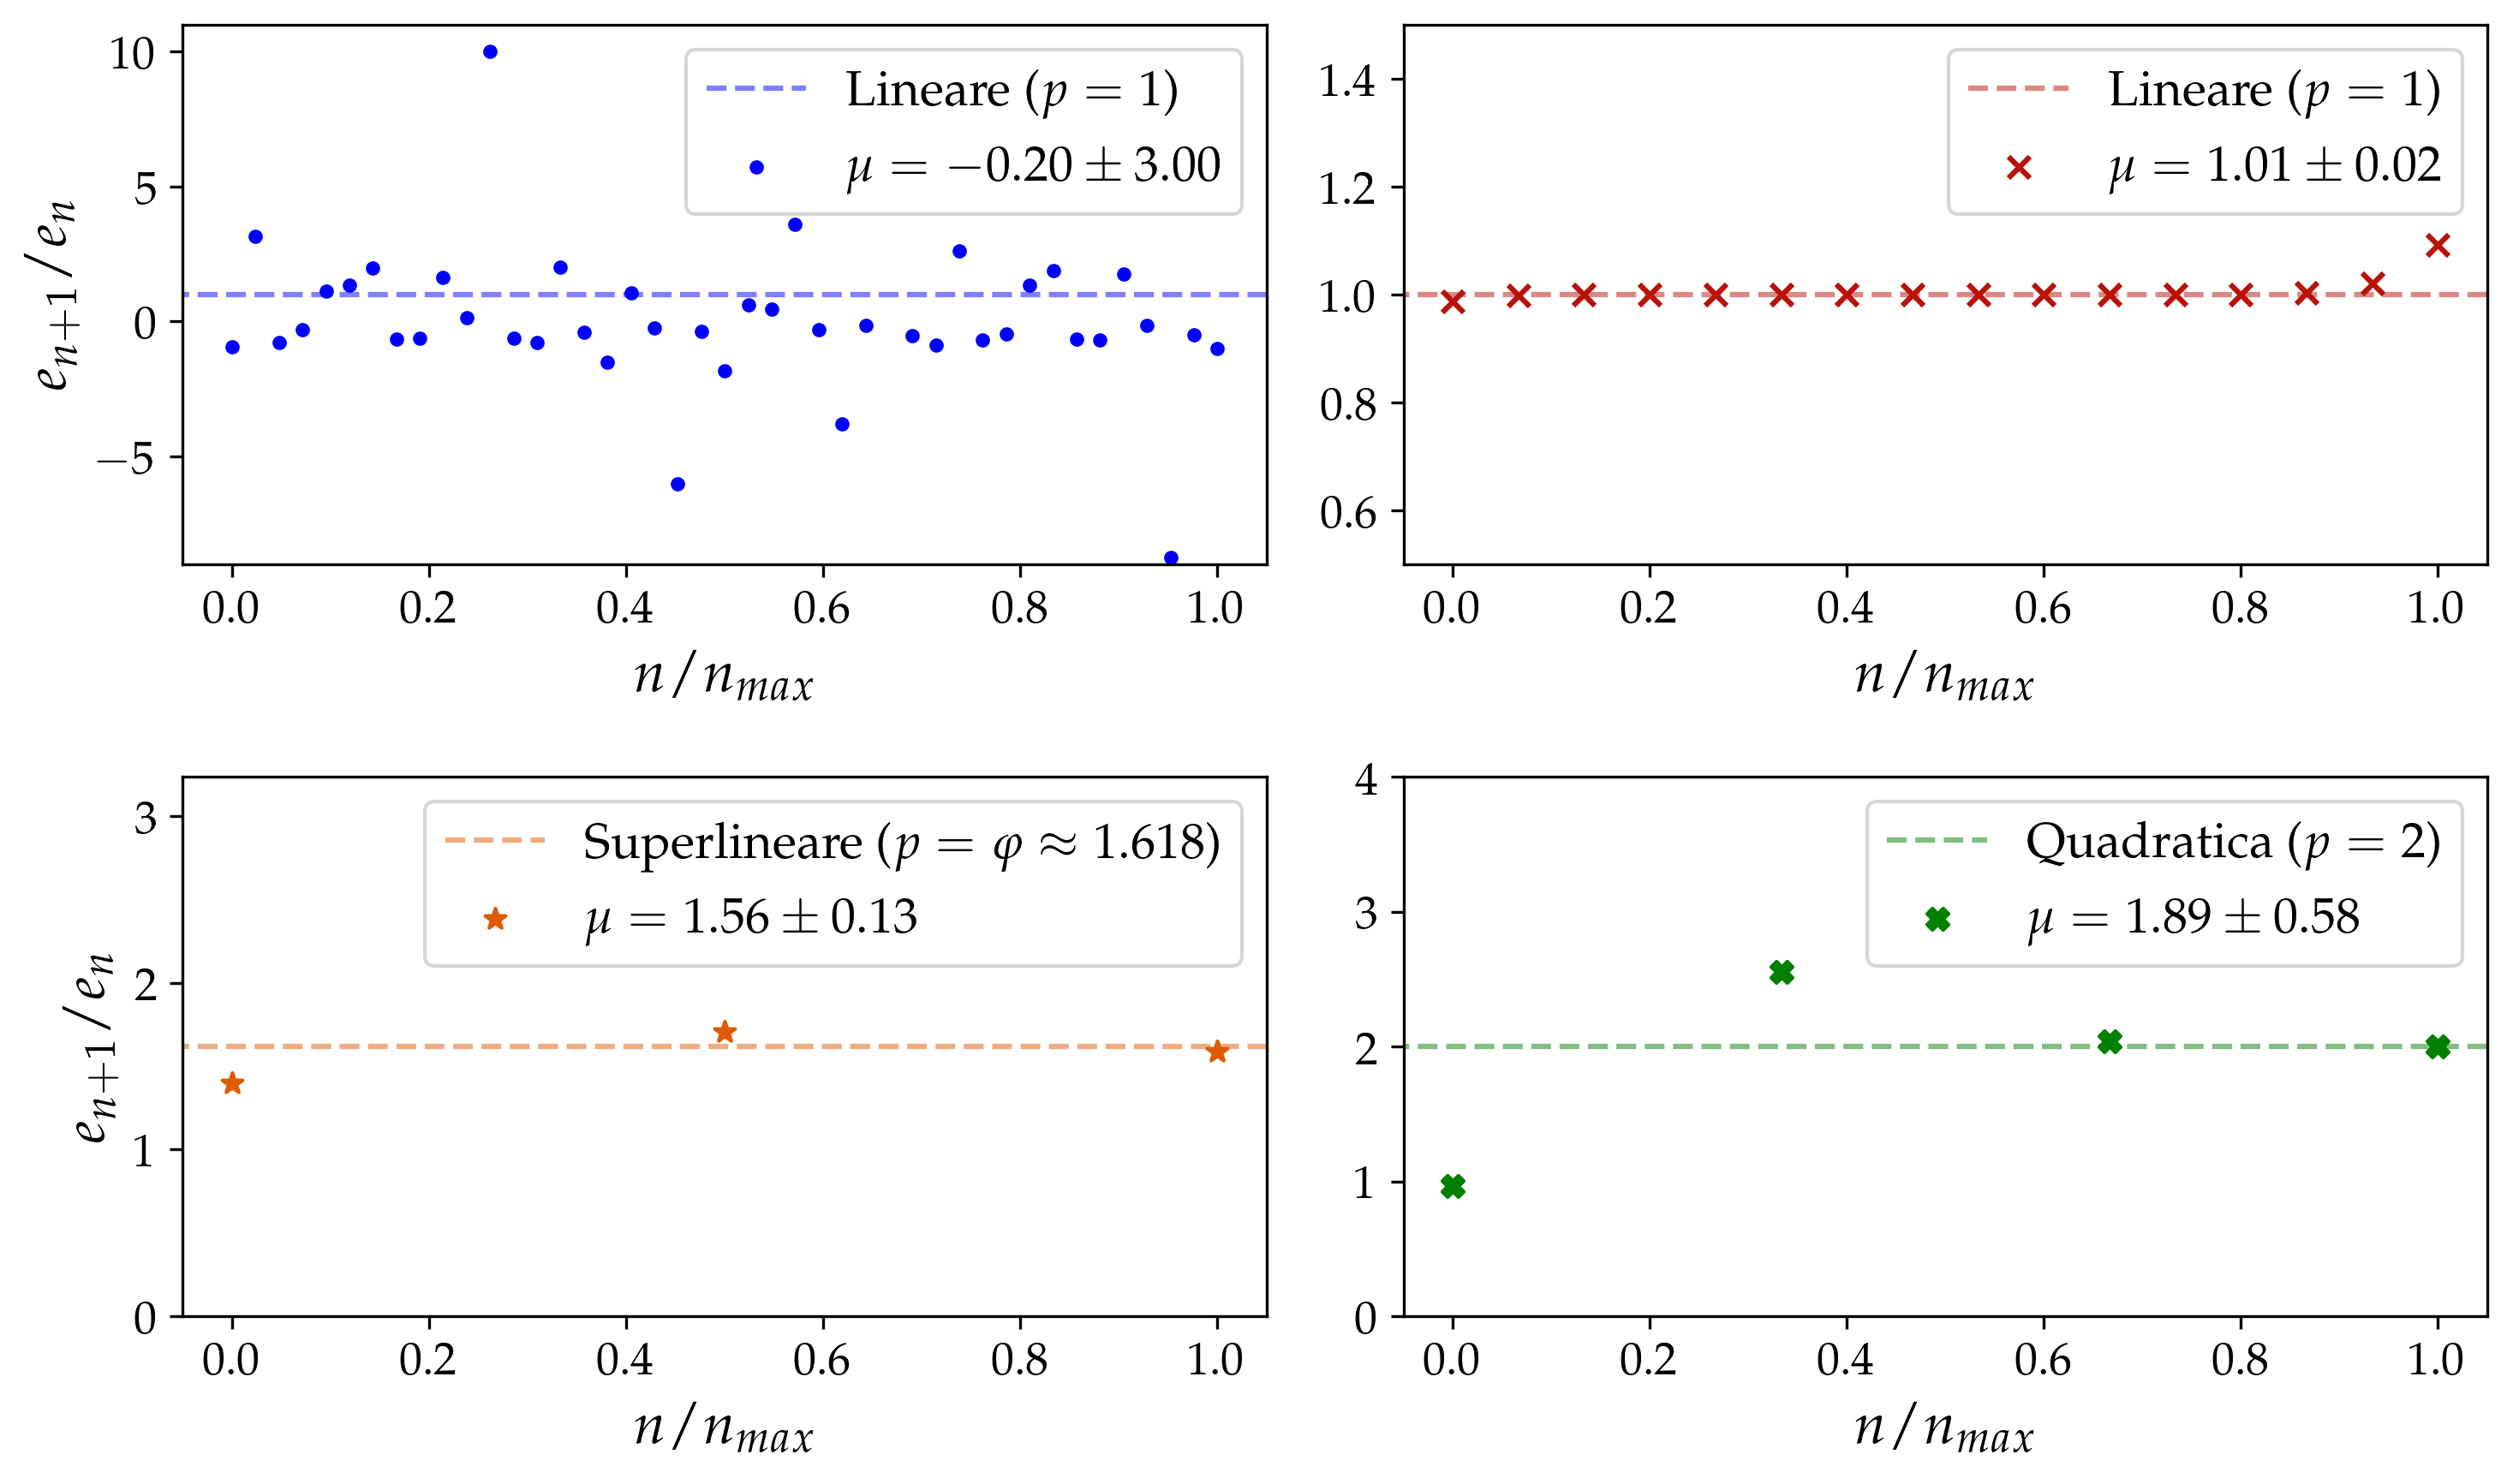

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 6))
fig_mul, axes = plt.subplots(2,2, figsize=(10, 6))
axes = axes.flatten()
ax2, ax5, ax3, ax4 = axes
min_err = 1e-14
max_err = 10
phi = (1 + np.sqrt(5)) / 2

ax1.set_xlim(8e-14, 3)
ax1.set_ylim(bottom=min_err, top=max_err)

ax2.set_ylim(bottom=-9, top=11)
ax3.set_ylim(bottom=0, top=2*phi)
ax4.set_ylim(bottom=0, top=4)
ax5.set_ylim(bottom=0.5, top=1.5)
colors = ['blue',"#B91209", '#DE5A03', 'green']

x_ref = np.logspace(-15, 2, 10)

lin_k = 1/2**(b_bis - a_bis)
parab_coeff = 1/2 * d2f_odd(c_NR)/df_odd(c_NR) 

ax1.plot(x_ref, lin_k*x_ref, '--', color=colors[0], alpha=0.5, label=r'Lineare ($p=1$)')
ax1.plot(x_ref, parab_coeff*x_ref**phi, '--', color=colors[2], alpha=0.5, label=r'Superlineare ($p=\varphi\approx 1.618$)')
ax1.plot(x_ref, parab_coeff*x_ref**2, '--', color=colors[3], alpha=0.5, label=r'Quadratica ($p=2$)')
hxcoo = 10
ax2.hlines(1, -hxcoo, hxcoo, ls='--', label=r'Lineare ($p=1$)', color=colors[0], alpha=0.5)
ax5.hlines(1, -hxcoo, hxcoo, ls='--', label=r'Lineare ($p=1$)', color=colors[1], alpha=0.5)
ax3.hlines(phi, -hxcoo, hxcoo, ls='--', label=r'Superlineare ($p=\varphi\approx 1.618$)', color=colors[2], alpha=0.5)
ax4.hlines(2, -hxcoo, hxcoo, ls='--', label=r'Quadratica ($p=2$)', color=colors[3], alpha=0.5 )

for i in range(4):
    story = np.array(stories[i])
    # Calcoliamo l'errore come distanza dall'ultimo valore trovato (la radice)
    err = abs(story - story[-1])
    
    # Definiamo e_k (errore attuale) e e_{k+1} (errore successivo)
    # Escludiamo l'ultimo punto perché l'errore è zero (log non definito)
    ek_minus_1 = err[:-3] 
    ek = err[1:-2] 
    ek_plus_1 = err[2:-1] 

    pk = np.log(ek_plus_1/ek) / np.log(ek/ek_minus_1)
    Kk = ek_plus_1/(ek**pk)

    p_mean = np.mean(pk)
    p_std = np.std(pk)

    markers = ['.', 'x', '*', 'X']
    ax1.loglog(ek, ek_plus_1, marker=markers[i], color=colors[i], ls='', ms=10, label=names[i])
    n_coo = np.linspace(0, 1, len(pk))
    axes[i].scatter(n_coo, pk, marker=markers[i], color=colors[i], label=rf'$\mu = {p_mean:.2f} \pm {p_std:.2f}$')
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_xlabel(r'$n/n_{max}$')
    axes[i].legend()

ax1.set_xlabel(r'$e_k$')
ax1.set_ylabel(r'$e_{k+1}$')
ax1.legend()
axes[0].set_ylabel(r'$e_{n+1}/e_n$')
axes[2].set_ylabel(r'$e_{n+1}/e_n$')
plt.tight_layout()

fig.savefig('plots/scat_lines_odd.png')
fig_mul.savefig('plots/single_scat_odd.png')
plt.show()